In [1]:
# ============================================================
# PROJECT 20 — MARKET BASKET ANALYSIS & CROSS-SELL INTELLIGENCE
# STEP 1 — TRANSACTION PREPARATION
# ============================================================

import io
import zipfile
import requests
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

print("=" * 90)
print("PROJECT 20 — MARKET BASKET ANALYSIS & CROSS-SELL INTELLIGENCE")
print("=" * 90)

# ------------------------------------------------------------
# 1. Download Online Retail II
# ------------------------------------------------------------

url = (
    "https://archive.ics.uci.edu/"
    "static/public/502/online+retail+ii.zip"
)

print("\nDownloading dataset...")

response = requests.get(
    url,
    timeout=120
)

response.raise_for_status()

print(
    f"Downloaded size: "
    f"{len(response.content) / (1024**2):.2f} MB"
)

# ------------------------------------------------------------
# 2. Open ZIP
# ------------------------------------------------------------

with zipfile.ZipFile(
    io.BytesIO(response.content)
) as z:

    excel_files = [
        file
        for file in z.namelist()
        if file.lower().endswith(
            (".xlsx", ".xls")
        )
    ]

    if not excel_files:
        raise FileNotFoundError(
            "Excel dataset tidak ditemukan."
        )

    excel_file = excel_files[0]

    print(
        "\nSelected file:",
        excel_file
    )

    excel_content = z.read(
        excel_file
    )

# ------------------------------------------------------------
# 3. Read all sheets
# ------------------------------------------------------------

xls = pd.ExcelFile(
    io.BytesIO(
        excel_content
    )
)

print(
    "\nAvailable sheets:"
)

for sheet in xls.sheet_names:
    print(
        " -",
        sheet
    )

frames = []

for sheet_name in xls.sheet_names:

    print(
        f"\nLoading: {sheet_name}"
    )

    temp = pd.read_excel(
        xls,
        sheet_name=sheet_name
    )

    temp[
        "Source_Sheet"
    ] = sheet_name

    frames.append(
        temp
    )

raw_df = pd.concat(
    frames,
    ignore_index=True
)

# ------------------------------------------------------------
# 4. Standardize columns
# ------------------------------------------------------------

raw_df = raw_df.rename(
    columns={
        "Invoice": "InvoiceNo",
        "StockCode": "StockCode",
        "Description": "Description",
        "Quantity": "Quantity",
        "InvoiceDate": "InvoiceDate",
        "Price": "UnitPrice",
        "Customer ID": "CustomerID",
        "Country": "Country"
    }
)

# ------------------------------------------------------------
# 5. Convert data types
# ------------------------------------------------------------

raw_df[
    "InvoiceDate"
] = pd.to_datetime(
    raw_df[
        "InvoiceDate"
    ],
    errors="coerce"
)

raw_df[
    "Quantity"
] = pd.to_numeric(
    raw_df[
        "Quantity"
    ],
    errors="coerce"
)

raw_df[
    "UnitPrice"
] = pd.to_numeric(
    raw_df[
        "UnitPrice"
    ],
    errors="coerce"
)

raw_df[
    "CustomerID"
] = pd.to_numeric(
    raw_df[
        "CustomerID"
    ],
    errors="coerce"
)

# ------------------------------------------------------------
# 6. Initial dataset profiling
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "RAW DATASET"
)

print(
    "=" * 90
)

print(
    f"\nRows     : {len(raw_df):,}"
)

print(
    f"Columns  : {len(raw_df.columns)}"
)

print(
    f"Customers: "
    f"{raw_df['CustomerID'].nunique(dropna=True):,}"
)

print(
    f"Invoices : "
    f"{raw_df['InvoiceNo'].nunique(dropna=True):,}"
)

# ------------------------------------------------------------
# 7. Remove missing customer identifiers
# ------------------------------------------------------------

basket_df = (
    raw_df[
        raw_df[
            "CustomerID"
        ].notna()
    ]
    .copy()
)

# ------------------------------------------------------------
# 8. Remove duplicate transaction rows
# ------------------------------------------------------------

duplicate_count = (
    basket_df
    .duplicated()
    .sum()
)

basket_df = (
    basket_df
    .drop_duplicates()
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 9. Standardize invoice number
# ------------------------------------------------------------

basket_df[
    "InvoiceNo"
] = (
    basket_df[
        "InvoiceNo"
    ]
    .astype(str)
    .str.strip()
)

# ------------------------------------------------------------
# 10. Identify cancelled invoices
# ------------------------------------------------------------

basket_df[
    "IsCancellation"
] = (
    basket_df[
        "InvoiceNo"
    ]
    .str.upper()
    .str.startswith("C")
)

cancellation_count = (
    basket_df[
        "IsCancellation"
    ].sum()
)

# ------------------------------------------------------------
# 11. Remove cancellations
# ------------------------------------------------------------

basket_df = (
    basket_df[
        ~basket_df[
            "IsCancellation"
        ]
    ]
    .copy()
)

# ------------------------------------------------------------
# 12. Keep valid positive quantities
# ------------------------------------------------------------

basket_df = (
    basket_df[
        (
            basket_df[
                "Quantity"
            ] > 0
        )
        &
        (
            basket_df[
                "UnitPrice"
            ] > 0
        )
        &
        (
            basket_df[
                "InvoiceDate"
            ].notna()
        )
    ]
    .copy()
)

# ------------------------------------------------------------
# 13. Clean product information
# ------------------------------------------------------------

basket_df[
    "StockCode"
] = (
    basket_df[
        "StockCode"
    ]
    .astype(str)
    .str.strip()
)

basket_df[
    "Description"
] = (
    basket_df[
        "Description"
    ]
    .fillna(
        "Unknown Product"
    )
    .astype(str)
    .str.strip()
)

# ------------------------------------------------------------
# 14. Remove invalid product descriptions
# ------------------------------------------------------------

invalid_description_mask = (
    basket_df[
        "Description"
    ]
    .str.lower()
    .isin(
        [
            "",
            "nan",
            "unknown product"
        ]
    )
)

invalid_description_count = (
    invalid_description_mask
    .sum()
)

basket_df = (
    basket_df[
        ~invalid_description_mask
    ]
    .copy()
)

# ------------------------------------------------------------
# 15. Calculate revenue
# ------------------------------------------------------------

basket_df[
    "Revenue"
] = (
    basket_df[
        "Quantity"
    ]
    *
    basket_df[
        "UnitPrice"
    ]
)

# ------------------------------------------------------------
# 16. Remove helper column
# ------------------------------------------------------------

basket_df = (
    basket_df
    .drop(
        columns=[
            "IsCancellation"
        ]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 17. Transaction-level statistics
# ------------------------------------------------------------

unique_transactions = (
    basket_df[
        "InvoiceNo"
    ].nunique()
)

unique_customers = (
    basket_df[
        "CustomerID"
    ].nunique()
)

unique_products = (
    basket_df[
        "StockCode"
    ].nunique()
)

total_units = (
    basket_df[
        "Quantity"
    ].sum()
)

total_revenue = (
    basket_df[
        "Revenue"
    ].sum()
)

# ------------------------------------------------------------
# 18. Basket size analysis
# ------------------------------------------------------------

basket_sizes = (
    basket_df
    .groupby(
        "InvoiceNo"
    )[
        "StockCode"
    ]
    .nunique()
)

# ------------------------------------------------------------
# 19. Final summary
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "BASKET DATA PREPARATION SUMMARY"
)

print(
    "=" * 90
)

print(
    f"\nOriginal rows              : "
    f"{len(raw_df):,}"
)

print(
    f"Missing CustomerID rows   : "
    f"{raw_df['CustomerID'].isna().sum():,}"
)

print(
    f"Duplicate rows removed    : "
    f"{duplicate_count:,}"
)

print(
    f"Cancellations removed     : "
    f"{cancellation_count:,}"
)

print(
    f"Invalid descriptions      : "
    f"{invalid_description_count:,}"
)

print(
    f"\nFinal transaction lines    : "
    f"{len(basket_df):,}"
)

print(
    f"Unique transactions       : "
    f"{unique_transactions:,}"
)

print(
    f"Unique customers          : "
    f"{unique_customers:,}"
)

print(
    f"Unique products           : "
    f"{unique_products:,}"
)

print(
    f"Total units sold          : "
    f"{total_units:,}"
)

print(
    f"Total revenue             : "
    f"{total_revenue:,.2f}"
)

print(
    "\nBasket size statistics:"
)

display(
    basket_sizes.describe()
    .to_frame(
        "Products_Per_Basket"
    )
)

# ------------------------------------------------------------
# 20. Top products by transaction frequency
# ------------------------------------------------------------

product_frequency = (
    basket_df
    .groupby(
        [
            "StockCode",
            "Description"
        ]
    )
    .agg(
        Transactions=(
            "InvoiceNo",
            "nunique"
        ),
        Units_Sold=(
            "Quantity",
            "sum"
        ),
        Revenue=(
            "Revenue",
            "sum"
        )
    )
    .sort_values(
        "Transactions",
        ascending=False
    )
)

print(
    "\n" + "=" * 90
)

print(
    "TOP PRODUCTS BY BASKET FREQUENCY"
)

print(
    "=" * 90
)

display(
    product_frequency.head(20)
)

# ------------------------------------------------------------
# 21. Final dataset preview
# ------------------------------------------------------------

print(
    "\nFinal basket transaction sample:"
)

display(
    basket_df[
        [
            "InvoiceNo",
            "CustomerID",
            "StockCode",
            "Description",
            "Quantity",
            "InvoiceDate",
            "Revenue"
        ]
    ].head(10)
)

print(
    "\nSTEP 1 completed successfully."
)

PROJECT 20 — MARKET BASKET ANALYSIS & CROSS-SELL INTELLIGENCE

Downloaded size: 43.51 MB

Selected file: online_retail_II.xlsx

Available sheets:
 - Year 2009-2010
 - Year 2010-2011

Loading: Year 2009-2010

Loading: Year 2010-2011

RAW DATASET

Rows     : 1,067,371
Columns  : 9
Customers: 5,942
Invoices : 53,628

BASKET DATA PREPARATION SUMMARY

Original rows              : 1,067,371
Missing CustomerID rows   : 243,007
Duplicate rows removed    : 11,996
Cancellations removed     : 18,688
Invalid descriptions      : 0

Final transaction lines    : 793,609
Unique transactions       : 36,969
Unique customers          : 5,878
Unique products           : 4,631
Total units sold          : 10,671,581
Total revenue             : 17,685,460.64

Basket size statistics:


,Products_Per_Basket
count,36969.000000
mean,20.797560
std,22.399873
min,1.000000
25%,6.000000
50%,15.000000
75%,27.000000
max,541.000000



TOP PRODUCTS BY BASKET FREQUENCY


,,Transactions,Units_Sold,Revenue
StockCode,Description,,,
85123A,WHITE HANGING HEART T-LIGHT HOLDER,4888,93520,251731.26
22423,REGENCY CAKESTAND 3 TIER,3317,24858,285992.35
84879,ASSORTED COLOUR BIRD ORNAMENT,2652,79694,126704.06
85099B,JUMBO BAG RED RETROSPOT,2612,75597,136684.79
47566,PARTY BUNTING,2077,23591,103802.53
20727,LUNCH BAG BLACK SKULL.,1997,25738,40450.90
22382,LUNCH BAG SPACEBOY DESIGN,1874,18963,30344.55
21034,REX CASH+CARRY JUMBO SHOPPER,1857,3962,3763.90
21754,HOME BUILDING BLOCK WORD,1831,7417,43532.81



Final basket transaction sample:


,InvoiceNo,CustomerID,StockCode,Description,Quantity,InvoiceDate,Revenue
0,489434,13085.0,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,83.4
1,489434,13085.0,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,81.0
2,489434,13085.0,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,81.0
3,489434,13085.0,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,100.8
4,489434,13085.0,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,30.0
5,489434,13085.0,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,39.6
6,489434,13085.0,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,30.0
7,489434,13085.0,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,59.5
8,489435,13085.0,22350,CAT BOWL,12,2009-12-01 07:46:00,30.6
9,489435,13085.0,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,45.0



STEP 1 completed successfully.


BASKET CONSTRUCTION & FREQUENT ITEMSET MINING

PRODUCT FREQUENCY FILTER

Total products before filter : 4,631
Minimum transaction support  : 0.50%
Products after filter        : 1,180
Products removed             : 3,451

Transactions before filter  : 36,969
Transaction lines after filter: 604,451

Creating sparse basket matrix...
Basket matrix shape: (35916, 1180)
Memory usage: 42.30 MB
Basket matrix density: 1.380%

Running FP-Growth...

FP-GROWTH RESULTS

Minimum support: 1.00%
Total frequent itemsets: 899
Frequent single products: 574
Frequent product pairs: 271
Frequent product triplets: 54

TOP FREQUENT SINGLE PRODUCTS


,Items,support,Support_Pct
0,[85123A — WHITE HANGING HEART T-LIGHT HOLDER],0.136290,13.629023
1,[22423 — REGENCY CAKESTAND 3 TIER],0.092354,9.235438
2,[85099B — JUMBO BAG RED WHITE SPOTTY],0.090767,9.076735
3,[84879 — ASSORTED COLOUR BIRD ORNAMENT],0.073839,7.383896
4,[20725 — LUNCH BAG RED SPOTTY],0.071806,7.180644
5,[21212 — PACK OF 72 RETRO SPOT CAKE CASES],0.069830,6.982960
6,[47566 — PARTY BUNTING],0.057829,5.782938
7,[22383 — LUNCHBAG SUKI DESIGN],0.055797,5.579686
8,[20727 — LUNCH BAG BLACK SKULL.],0.055602,5.560196
9,[22382 — LUNCHBAG SPACEBOY DESIGN],0.053430,5.343023



TOP FREQUENT PRODUCT PAIRS


,Items,support,Support_Pct
574,"[21733 — RED HANGING HEART T-LIGHT HOLDER, 851...",0.032158,3.215837
575,"[85099B — JUMBO BAG RED WHITE SPOTTY, 22386 — ...",0.029625,2.962468
576,"[22384 — LUNCHBAG PINK RETROSPOT, 20725 — LUNC...",0.028455,2.845528
577,"[20725 — LUNCH BAG RED SPOTTY, 20727 — LUNCH B...",0.028093,2.809333
578,"[82482 — WOODEN PICTURE FRAME WHITE FINISH, 82...",0.027648,2.764784
579,"[22383 — LUNCHBAG SUKI DESIGN, 20725 — LUNCH ...",0.027175,2.717452
580,"[85099B — JUMBO BAG RED WHITE SPOTTY, 85099F —...",0.026506,2.650629
581,"[84991 — 60 TEATIME FAIRY CAKE CASES, 21212 — ...",0.025420,2.542043
582,"[85099B — JUMBO BAG RED WHITE SPOTTY, 21931 — ...",0.025420,2.542043
583,"[22382 — LUNCHBAG SPACEBOY DESIGN, 22383 — LUN...",0.025309,2.530905



TOP FREQUENT PRODUCT TRIPLETS


,Items,support,Support_Pct
845,"[22384 — LUNCHBAG PINK RETROSPOT, 20725 — LUNC...",0.015481,1.548057
846,"[22697 — GREEN REGENCY TEACUP AND SAUCER, 2269...",0.015091,1.509077
847,"[22383 — LUNCHBAG SUKI DESIGN, 22384 — LUNCHB...",0.015063,1.506292
848,"[22382 — LUNCHBAG SPACEBOY DESIGN, 22383 — LUN...",0.014283,1.428333
849,"[22384 — LUNCHBAG PINK RETROSPOT, 20725 — LUNC...",0.014255,1.425549
850,"[22383 — LUNCHBAG SUKI DESIGN, 20725 — LUNCH ...",0.014005,1.400490
851,"[22383 — LUNCHBAG SUKI DESIGN, 20725 — LUNCH ...",0.013838,1.383784
852,"[22382 — LUNCHBAG SPACEBOY DESIGN, 20725 — LUN...",0.013532,1.353157
853,"[85099B — JUMBO BAG RED WHITE SPOTTY, 22386 — ...",0.013420,1.342020
854,"[22383 — LUNCHBAG SUKI DESIGN, 20725 — LUNCH ...",0.013337,1.333667


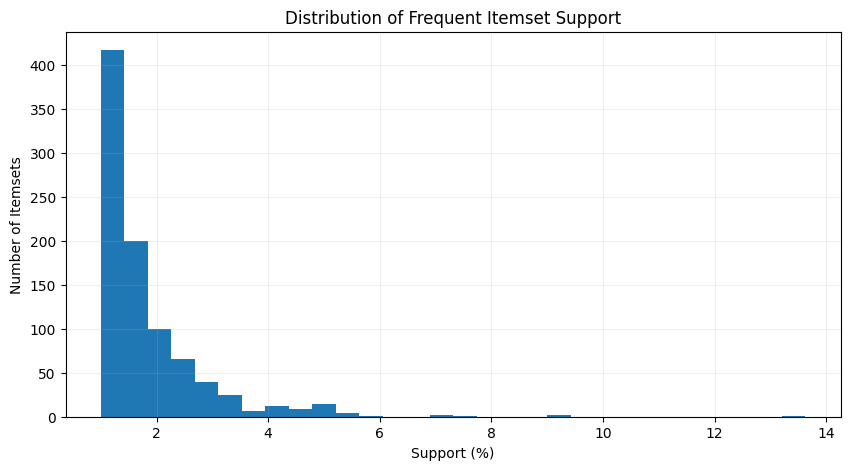


ITEMSET SIZE SUMMARY


,Item_Count,Itemset_Count
0,1,574
1,2,271
2,3,54



BASKET SUMMARY


,Metric,Value
0,Transactions,36969.000000
1,Products Before Filter,4631.000000
2,Products After Filter,1180.000000
3,Average Basket Size Before Filter,20.797560
4,Average Basket Size After Filter,16.279625
5,Minimum Basket Size,1.000000
6,Maximum Basket Size,376.000000



STEP 2 STATUS
PASS — Basket construction and FP-Growth completed.


In [2]:
# ============================================================
# PROJECT 20 — MARKET BASKET ANALYSIS & CROSS-SELL INTELLIGENCE
# STEP 2 — BASKET CONSTRUCTION & FREQUENT ITEMSET MINING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import fpgrowth

import warnings
warnings.filterwarnings("ignore")

print("=" * 90)
print("BASKET CONSTRUCTION & FREQUENT ITEMSET MINING")
print("=" * 90)

# ------------------------------------------------------------
# 1. Validate input data
# ------------------------------------------------------------

required_columns = [
    "InvoiceNo",
    "StockCode",
    "Description",
    "Quantity"
]

missing_columns = [
    col
    for col in required_columns
    if col not in basket_df.columns
]

if missing_columns:

    raise ValueError(
        f"Missing columns: {missing_columns}"
    )

# ------------------------------------------------------------
# 2. Create product labels
# ------------------------------------------------------------

product_lookup = (
    basket_df[
        [
            "StockCode",
            "Description"
        ]
    ]
    .drop_duplicates(
        subset=["StockCode"]
    )
    .copy()
)

product_lookup[
    "Product_Label"
] = (
    product_lookup["StockCode"]
    .astype(str)
    + " — "
    + product_lookup["Description"]
    .astype(str)
    .str[:60]
)

# ------------------------------------------------------------
# 3. Calculate product transaction support
# ------------------------------------------------------------

product_transaction_count = (
    basket_df
    .groupby(
        "StockCode"
    )[
        "InvoiceNo"
    ]
    .nunique()
    .sort_values(
        ascending=False
    )
)

total_transactions = (
    basket_df[
        "InvoiceNo"
    ]
    .nunique()
)

product_support = (
    product_transaction_count
    /
    total_transactions
)

product_frequency = pd.DataFrame({
    "Transactions":
        product_transaction_count,

    "Support":
        product_support
})

# ------------------------------------------------------------
# 4. Filter very rare products
# ------------------------------------------------------------

# Minimum 0.5% transaction support
min_product_support = 0.005

frequent_products = (
    product_support[
        product_support
        >= min_product_support
    ]
    .index
)

filtered_basket = (
    basket_df[
        basket_df[
            "StockCode"
        ].isin(
            frequent_products
        )
    ]
    .copy()
)

# ------------------------------------------------------------
# 5. Basket size before and after filtering
# ------------------------------------------------------------

original_basket_size = (
    basket_df
    .groupby(
        "InvoiceNo"
    )[
        "StockCode"
    ]
    .nunique()
)

filtered_basket_size = (
    filtered_basket
    .groupby(
        "InvoiceNo"
    )[
        "StockCode"
    ]
    .nunique()
)

# ------------------------------------------------------------
# 6. Display product filtering
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "PRODUCT FREQUENCY FILTER"
)

print(
    "=" * 90
)

print(
    f"\nTotal products before filter : "
    f"{basket_df['StockCode'].nunique():,}"
)

print(
    f"Minimum transaction support  : "
    f"{min_product_support * 100:.2f}%"
)

print(
    f"Products after filter        : "
    f"{len(frequent_products):,}"
)

print(
    f"Products removed             : "
    f"{basket_df['StockCode'].nunique() - len(frequent_products):,}"
)

print(
    f"\nTransactions before filter  : "
    f"{total_transactions:,}"
)

print(
    f"Transaction lines after filter: "
    f"{len(filtered_basket):,}"
)

# ------------------------------------------------------------
# 7. Create binary basket matrix
# ------------------------------------------------------------

print(
    "\nCreating sparse basket matrix..."
)

# Group by invoice and product first
basket_pairs = (
    filtered_basket[
        [
            "InvoiceNo",
            "StockCode"
        ]
    ]
    .drop_duplicates()
)

# Pivot into transaction × product matrix
basket_matrix = (
    basket_pairs
    .assign(
        Purchased=1
    )
    .pivot_table(
        index="InvoiceNo",
        columns="StockCode",
        values="Purchased",
        fill_value=0,
        aggfunc="max"
    )
)

# Convert to compact integer type
basket_matrix = (
    basket_matrix
    .astype("uint8")
)

print(
    f"Basket matrix shape: "
    f"{basket_matrix.shape}"
)

print(
    f"Memory usage: "
    f"{basket_matrix.memory_usage(deep=True).sum() / (1024**2):.2f} MB"
)

# ------------------------------------------------------------
# 8. Basket density
# ------------------------------------------------------------

basket_density = (
    basket_matrix.values.mean()
)

print(
    f"Basket matrix density: "
    f"{basket_density * 100:.3f}%"
)

# ------------------------------------------------------------
# 9. Run FP-Growth
# ------------------------------------------------------------

print(
    "\nRunning FP-Growth..."
)

min_support = 0.01

frequent_itemsets = fpgrowth(
    basket_matrix,
    min_support=min_support,
    use_colnames=True,
    max_len=3
)

# ------------------------------------------------------------
# 10. Add itemset size
# ------------------------------------------------------------

frequent_itemsets[
    "Itemset_Size"
] = (
    frequent_itemsets[
        "itemsets"
    ]
    .apply(
        len
    )
)

frequent_itemsets[
    "Support_Pct"
] = (
    frequent_itemsets[
        "support"
    ]
    * 100
)

# ------------------------------------------------------------
# 11. Add readable product descriptions
# ------------------------------------------------------------

description_map = dict(
    zip(
        product_lookup[
            "StockCode"
        ],
        product_lookup[
            "Description"
        ]
    )
)

def readable_itemset(itemset):

    labels = []

    for code in itemset:

        description = (
            description_map
            .get(
                code,
                "Unknown Product"
            )
        )

        labels.append(
            f"{code} — {description}"
        )

    return labels

frequent_itemsets[
    "Items"
] = (
    frequent_itemsets[
        "itemsets"
    ]
    .apply(
        readable_itemset
    )
)

frequent_itemsets[
    "Item_Count"
] = (
    frequent_itemsets[
        "itemsets"
    ]
    .apply(
        len
    )
)

# ------------------------------------------------------------
# 12. Sort itemsets by support
# ------------------------------------------------------------

frequent_itemsets = (
    frequent_itemsets
    .sort_values(
        [
            "Itemset_Size",
            "support"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 13. Separate itemsets by size
# ------------------------------------------------------------

frequent_singletons = (
    frequent_itemsets[
        frequent_itemsets[
            "Item_Count"
        ] == 1
    ]
    .copy()
)

frequent_pairs = (
    frequent_itemsets[
        frequent_itemsets[
            "Item_Count"
        ] == 2
    ]
    .copy()
)

frequent_triplets = (
    frequent_itemsets[
        frequent_itemsets[
            "Item_Count"
        ] == 3
    ]
    .copy()
)

# ------------------------------------------------------------
# 14. Print mining results
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "FP-GROWTH RESULTS"
)

print(
    "=" * 90
)

print(
    f"\nMinimum support: "
    f"{min_support * 100:.2f}%"
)

print(
    f"Total frequent itemsets: "
    f"{len(frequent_itemsets):,}"
)

print(
    f"Frequent single products: "
    f"{len(frequent_singletons):,}"
)

print(
    f"Frequent product pairs: "
    f"{len(frequent_pairs):,}"
)

print(
    f"Frequent product triplets: "
    f"{len(frequent_triplets):,}"
)

# ------------------------------------------------------------
# 15. Top single products
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "TOP FREQUENT SINGLE PRODUCTS"
)

print(
    "=" * 90
)

display(
    frequent_singletons[
        [
            "Items",
            "support",
            "Support_Pct"
        ]
    ]
    .head(20)
)

# ------------------------------------------------------------
# 16. Top product pairs
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "TOP FREQUENT PRODUCT PAIRS"
)

print(
    "=" * 90
)

display(
    frequent_pairs[
        [
            "Items",
            "support",
            "Support_Pct"
        ]
    ]
    .head(30)
)

# ------------------------------------------------------------
# 17. Top product triplets
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "TOP FREQUENT PRODUCT TRIPLETS"
)

print(
    "=" * 90
)

display(
    frequent_triplets[
        [
            "Items",
            "support",
            "Support_Pct"
        ]
    ]
    .head(20)
)

# ------------------------------------------------------------
# 18. Support distribution
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 5)
)

plt.hist(
    frequent_itemsets[
        "Support_Pct"
    ],
    bins=30
)

plt.title(
    "Distribution of Frequent Itemset Support"
)

plt.xlabel(
    "Support (%)"
)

plt.ylabel(
    "Number of Itemsets"
)

plt.grid(
    alpha=0.2
)

plt.show()

# ------------------------------------------------------------
# 19. Number of itemsets by size
# ------------------------------------------------------------

itemset_size_summary = (
    frequent_itemsets
    .groupby(
        "Item_Count"
    )
    .size()
    .reset_index(
        name="Itemset_Count"
    )
)

print(
    "\n" + "=" * 90
)

print(
    "ITEMSET SIZE SUMMARY"
)

print(
    "=" * 90
)

display(
    itemset_size_summary
)

# ------------------------------------------------------------
# 20. Basket size comparison
# ------------------------------------------------------------

basket_summary = pd.DataFrame({
    "Metric": [
        "Transactions",
        "Products Before Filter",
        "Products After Filter",
        "Average Basket Size Before Filter",
        "Average Basket Size After Filter",
        "Minimum Basket Size",
        "Maximum Basket Size"
    ],

    "Value": [
        total_transactions,

        basket_df[
            "StockCode"
        ].nunique(),

        len(frequent_products),

        original_basket_size.mean(),

        filtered_basket_size.mean(),

        filtered_basket_size.min(),

        filtered_basket_size.max()
    ]
})

print(
    "\n" + "=" * 90
)

print(
    "BASKET SUMMARY"
)

print(
    "=" * 90
)

display(
    basket_summary
)

# ------------------------------------------------------------
# 21. Store results
# ------------------------------------------------------------

market_basket_results = {
    "basket_matrix":
        basket_matrix,

    "product_frequency":
        product_frequency,

    "frequent_itemsets":
        frequent_itemsets,

    "frequent_singletons":
        frequent_singletons,

    "frequent_pairs":
        frequent_pairs,

    "frequent_triplets":
        frequent_triplets
}

# ------------------------------------------------------------
# 22. Final status
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "STEP 2 STATUS"
)

print(
    "=" * 90
)

print(
    "PASS — Basket construction and FP-Growth completed."
)

ASSOCIATION RULE MINING

Generating association rules...

ASSOCIATION RULE SUMMARY

Total rules generated : 844
Average support       : 1.350%
Average confidence    : 40.031%
Average lift          : 11.961
Maximum lift          : 53.644
Maximum confidence    : 89.59%

TOP ASSOCIATION RULES BY LIFT


,Antecedents_Readable,Consequents_Readable,support,confidence,lift,leverage,conviction
0,[22746 — POPPY'S PLAYHOUSE LIVINGROOM],[22745 — POPPY'S PLAYHOUSE BEDROOM],0.010636,0.830435,53.643697,0.010438,5.806140
1,[22745 — POPPY'S PLAYHOUSE BEDROOM],[22746 — POPPY'S PLAYHOUSE LIVINGROOM],0.010636,0.687050,53.643697,0.010438,3.154477
2,[22746 — POPPY'S PLAYHOUSE LIVINGROOM],[22748 — POPPY'S PLAYHOUSE KITCHEN],0.011360,0.886957,51.714173,0.011140,8.694432
3,[22748 — POPPY'S PLAYHOUSE KITCHEN],[22746 — POPPY'S PLAYHOUSE LIVINGROOM],0.011360,0.662338,51.714173,0.011140,2.923608
4,[22745 — POPPY'S PLAYHOUSE BEDROOM],[22748 — POPPY'S PLAYHOUSE KITCHEN],0.013142,0.848921,49.496496,0.012876,6.505523
5,[22748 — POPPY'S PLAYHOUSE KITCHEN],[22745 — POPPY'S PLAYHOUSE BEDROOM],0.013142,0.766234,49.496496,0.012876,4.211555
6,[21239 — PINK SPOTTY CUP],[21240 — BLUE SPOTTY CUP],0.010803,0.704174,44.526623,0.010560,3.326909
7,[21240 — BLUE SPOTTY CUP],[21239 — PINK SPOTTY CUP],0.010803,0.683099,44.526623,0.010560,3.107145
8,"[21899 — KEY FOB , GARAGE DESIGN]","[21900 — KEY FOB , SHED]",0.011388,0.782027,42.946901,0.011123,4.504181
9,"[21900 — KEY FOB , SHED]","[21899 — KEY FOB , GARAGE DESIGN]",0.011388,0.625382,42.946901,0.011123,2.630517



MEANINGFUL ASSOCIATION RULES

Total rules generated      : 844
Rules passing thresholds   : 741
Support threshold          : >= 0.50%
Confidence threshold       : >= 20.00%
Lift threshold             : >= 1.20

Top meaningful cross-sell rules:


,Antecedents_Readable,Consequents_Readable,Support_Pct,Confidence_Pct,lift,leverage,conviction
0,[22746 — POPPY'S PLAYHOUSE LIVINGROOM],[22745 — POPPY'S PLAYHOUSE BEDROOM],1.063593,83.043478,53.643697,0.010438,5.806140
1,[22745 — POPPY'S PLAYHOUSE BEDROOM],[22746 — POPPY'S PLAYHOUSE LIVINGROOM],1.063593,68.705036,53.643697,0.010438,3.154477
2,[22746 — POPPY'S PLAYHOUSE LIVINGROOM],[22748 — POPPY'S PLAYHOUSE KITCHEN],1.135984,88.695652,51.714173,0.011140,8.694432
3,[22748 — POPPY'S PLAYHOUSE KITCHEN],[22746 — POPPY'S PLAYHOUSE LIVINGROOM],1.135984,66.233766,51.714173,0.011140,2.923608
4,[22745 — POPPY'S PLAYHOUSE BEDROOM],[22748 — POPPY'S PLAYHOUSE KITCHEN],1.314178,84.892086,49.496496,0.012876,6.505523
5,[22748 — POPPY'S PLAYHOUSE KITCHEN],[22745 — POPPY'S PLAYHOUSE BEDROOM],1.314178,76.623377,49.496496,0.012876,4.211555
6,[21239 — PINK SPOTTY CUP],[21240 — BLUE SPOTTY CUP],1.080298,70.417423,44.526623,0.010560,3.326909
7,[21240 — BLUE SPOTTY CUP],[21239 — PINK SPOTTY CUP],1.080298,68.309859,44.526623,0.010560,3.107145
8,"[21899 — KEY FOB , GARAGE DESIGN]","[21900 — KEY FOB , SHED]",1.138768,78.202677,42.946901,0.011123,4.504181
9,"[21900 — KEY FOB , SHED]","[21899 — KEY FOB , GARAGE DESIGN]",1.138768,62.538226,42.946901,0.011123,2.630517



ONE-TO-ONE CROSS-SELL RULES


,Antecedent_Product,Antecedent_Description,Consequent_Product,Consequent_Description,Support_Pct,Confidence_Pct,lift
0,22746,POPPY'S PLAYHOUSE LIVINGROOM,22745,POPPY'S PLAYHOUSE BEDROOM,1.063593,83.043478,53.643697
1,22745,POPPY'S PLAYHOUSE BEDROOM,22746,POPPY'S PLAYHOUSE LIVINGROOM,1.063593,68.705036,53.643697
2,22746,POPPY'S PLAYHOUSE LIVINGROOM,22748,POPPY'S PLAYHOUSE KITCHEN,1.135984,88.695652,51.714173
3,22748,POPPY'S PLAYHOUSE KITCHEN,22746,POPPY'S PLAYHOUSE LIVINGROOM,1.135984,66.233766,51.714173
4,22745,POPPY'S PLAYHOUSE BEDROOM,22748,POPPY'S PLAYHOUSE KITCHEN,1.314178,84.892086,49.496496
5,22748,POPPY'S PLAYHOUSE KITCHEN,22745,POPPY'S PLAYHOUSE BEDROOM,1.314178,76.623377,49.496496
6,21239,PINK SPOTTY CUP,21240,BLUE SPOTTY CUP,1.080298,70.417423,44.526623
7,21240,BLUE SPOTTY CUP,21239,PINK SPOTTY CUP,1.080298,68.309859,44.526623
8,21899,"KEY FOB , GARAGE DESIGN",21900,"KEY FOB , SHED",1.138768,78.202677,42.946901
9,21900,"KEY FOB , SHED",21899,"KEY FOB , GARAGE DESIGN",1.138768,62.538226,42.946901



TOP RULES BY CONFIDENCE


,Antecedents_Readable,Consequents_Readable,Support_Pct,Confidence_Pct,lift
32,"[22698 — PINK REGENCY TEACUP AND SAUCER, 22699...",[22697 — GREEN REGENCY TEACUP AND SAUCER],1.509077,89.586777,34.012671
34,"[22423 — REGENCY CAKESTAND 3 TIER, 22698 — PIN...",[22697 — GREEN REGENCY TEACUP AND SAUCER],1.069161,89.095128,33.826011
2,[22746 — POPPY'S PLAYHOUSE LIVINGROOM],[22748 — POPPY'S PLAYHOUSE KITCHEN],1.135984,88.695652,51.714173
52,"[22423 — REGENCY CAKESTAND 3 TIER, 22698 — PIN...",[22699 — ROSES REGENCY TEACUP AND SAUCER],1.038534,86.542923,29.049305
54,"[22697 — GREEN REGENCY TEACUP AND SAUCER, 2269...",[22699 — ROSES REGENCY TEACUP AND SAUCER],1.509077,85.354331,28.650338
4,[22745 — POPPY'S PLAYHOUSE BEDROOM],[22748 — POPPY'S PLAYHOUSE KITCHEN],1.314178,84.892086,49.496496
40,[22698 — PINK REGENCY TEACUP AND SAUCER],[22697 — GREEN REGENCY TEACUP AND SAUCER],1.768014,84.105960,31.931815
62,"[22423 — REGENCY CAKESTAND 3 TIER, 22697 — GRE...",[22699 — ROSES REGENCY TEACUP AND SAUCER],1.233434,84.060721,28.216120
0,[22746 — POPPY'S PLAYHOUSE LIVINGROOM],[22745 — POPPY'S PLAYHOUSE BEDROOM],1.063593,83.043478,53.643697
16,[21124 — SET/10 BLUE SPOTTY PARTY CANDLES],[21122 — SET/10 PINK SPOTTY PARTY CANDLES],1.336452,80.133556,38.945559



BUSINESS-PRIORITY ASSOCIATION RULES


,Antecedents_Readable,Consequents_Readable,Support_Pct,Confidence_Pct,lift,Business_Score
0,"[22698 — PINK REGENCY TEACUP AND SAUCER, 22699...",[22697 — GREEN REGENCY TEACUP AND SAUCER],1.509077,89.586777,34.012671,0.391314
1,[22698 — PINK REGENCY TEACUP AND SAUCER],[22697 — GREEN REGENCY TEACUP AND SAUCER],1.768014,84.105960,31.931815,0.390793
2,[22697 — GREEN REGENCY TEACUP AND SAUCER],[22699 — ROSES REGENCY TEACUP AND SAUCER],2.099343,79.704017,26.753733,0.383796
3,[22745 — POPPY'S PLAYHOUSE BEDROOM],[22748 — POPPY'S PLAYHOUSE KITCHEN],1.314178,84.892086,49.496496,0.381673
4,[22746 — POPPY'S PLAYHOUSE LIVINGROOM],[22748 — POPPY'S PLAYHOUSE KITCHEN],1.135984,88.695652,51.714173,0.374817
5,"[22697 — GREEN REGENCY TEACUP AND SAUCER, 2269...",[22699 — ROSES REGENCY TEACUP AND SAUCER],1.509077,85.354331,28.650338,0.355397
6,[22698 — PINK REGENCY TEACUP AND SAUCER],[22699 — ROSES REGENCY TEACUP AND SAUCER],1.684486,80.132450,26.897543,0.346175
7,[22748 — POPPY'S PLAYHOUSE KITCHEN],[22745 — POPPY'S PLAYHOUSE BEDROOM],1.314178,76.623377,49.496496,0.344497
8,[21086 — SET/6 RED SPOTTY PAPER CUPS],[21094 — SET/6 RED SPOTTY PAPER PLATES],1.361510,78.743961,40.869481,0.343136
9,[22746 — POPPY'S PLAYHOUSE LIVINGROOM],[22745 — POPPY'S PLAYHOUSE BEDROOM],1.063593,83.043478,53.643697,0.342644


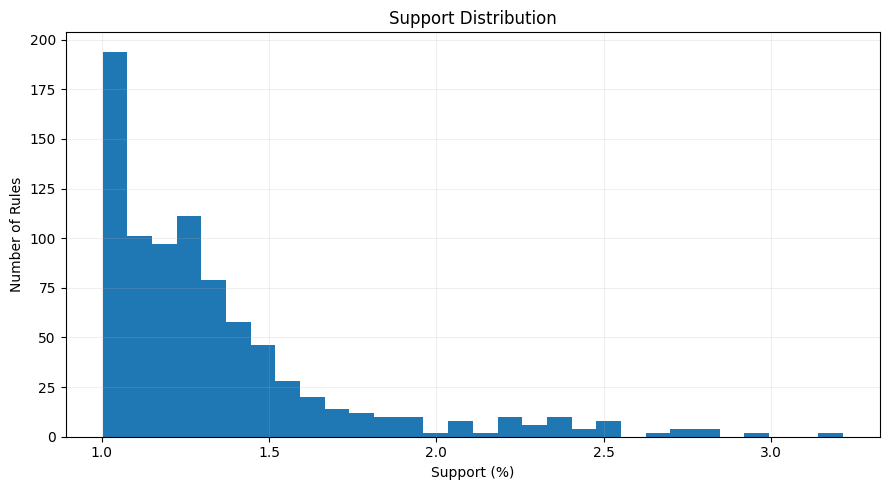

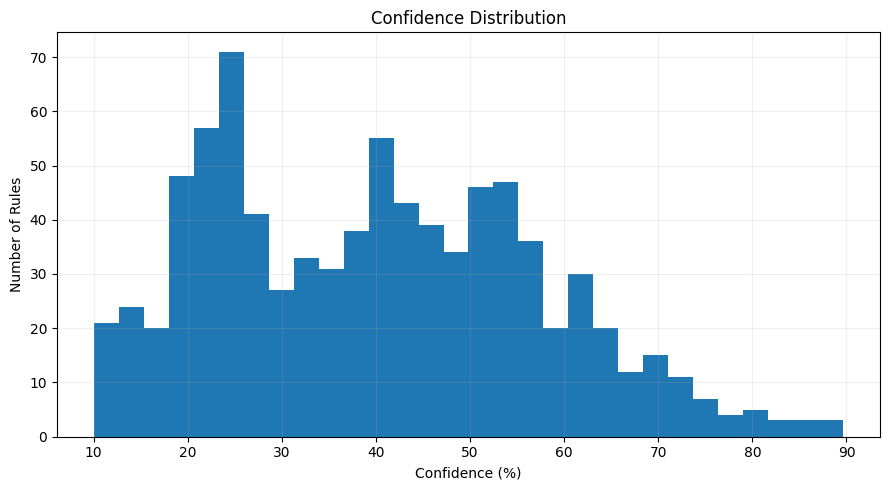

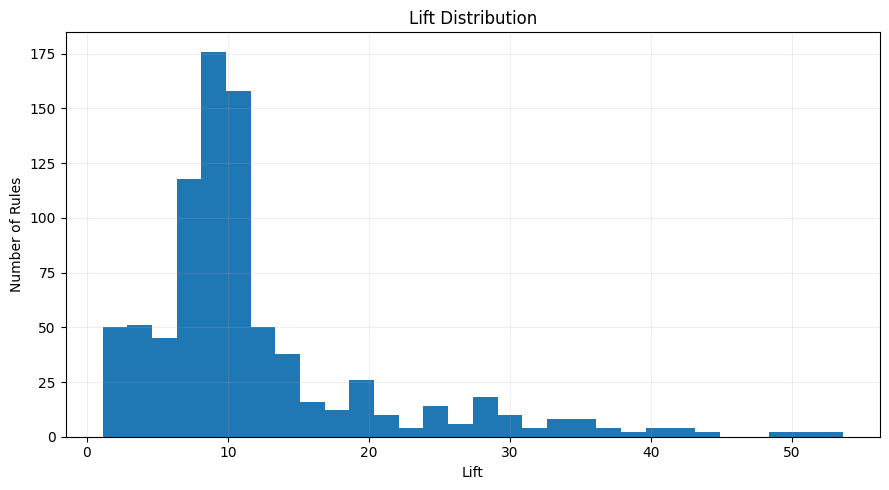

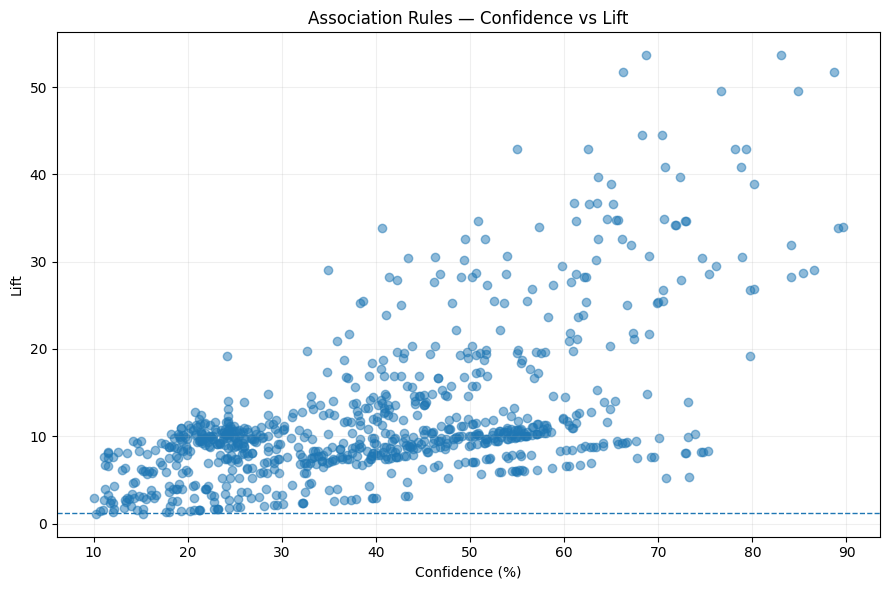


TOP 10 CROSS-SELL OPPORTUNITIES

1. 22698 — PINK REGENCY TEACUP AND SAUCER + 22699 — ROSES REGENCY TEACUP AND SAUCER  →  22697 — GREEN REGENCY TEACUP AND SAUCER
   Support    : 1.509%
   Confidence : 89.59%
   Lift       : 34.013

2. 22698 — PINK REGENCY TEACUP AND SAUCER  →  22697 — GREEN REGENCY TEACUP AND SAUCER
   Support    : 1.768%
   Confidence : 84.11%
   Lift       : 31.932

3. 22697 — GREEN REGENCY TEACUP AND SAUCER  →  22699 — ROSES REGENCY TEACUP AND SAUCER
   Support    : 2.099%
   Confidence : 79.70%
   Lift       : 26.754

4. 22745 — POPPY'S PLAYHOUSE BEDROOM  →  22748 — POPPY'S PLAYHOUSE KITCHEN
   Support    : 1.314%
   Confidence : 84.89%
   Lift       : 49.496

5. 22746 — POPPY'S PLAYHOUSE LIVINGROOM  →  22748 — POPPY'S PLAYHOUSE KITCHEN
   Support    : 1.136%
   Confidence : 88.70%
   Lift       : 51.714

6. 22697 — GREEN REGENCY TEACUP AND SAUCER + 22698 — PINK REGENCY TEACUP AND SAUCER  →  22699 — ROSES REGENCY TEACUP AND SAUCER
   Support    : 1.509%
   Confiden

In [3]:
# ============================================================
# PROJECT 20 — MARKET BASKET ANALYSIS & CROSS-SELL INTELLIGENCE
# STEP 3 — ASSOCIATION RULE MINING & RULE EVALUATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import association_rules

print("=" * 90)
print("ASSOCIATION RULE MINING")
print("=" * 90)

# ------------------------------------------------------------
# 1. Validate frequent itemsets
# ------------------------------------------------------------

if "frequent_itemsets" not in globals():
    raise ValueError(
        "frequent_itemsets tidak ditemukan. "
        "Jalankan STEP 2 terlebih dahulu."
    )

# ------------------------------------------------------------
# 2. Generate association rules
# ------------------------------------------------------------

print("\nGenerating association rules...")

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.10
)

# ------------------------------------------------------------
# 3. Add readable product descriptions
# ------------------------------------------------------------

description_map = dict(
    zip(
        product_lookup[
            "StockCode"
        ],
        product_lookup[
            "Description"
        ]
    )
)

def format_itemset(itemset):

    labels = []

    for code in sorted(itemset):

        description = (
            description_map.get(
                code,
                "Unknown Product"
            )
        )

        labels.append(
            f"{code} — {description}"
        )

    return labels

rules[
    "Antecedents_Readable"
] = (
    rules[
        "antecedents"
    ]
    .apply(
        format_itemset
    )
)

rules[
    "Consequents_Readable"
] = (
    rules[
        "consequents"
    ]
    .apply(
        format_itemset
    )
)

# ------------------------------------------------------------
# 4. Calculate rule size
# ------------------------------------------------------------

rules[
    "Antecedent_Size"
] = (
    rules[
        "antecedents"
    ]
    .apply(
        len
    )
)

rules[
    "Consequent_Size"
] = (
    rules[
        "consequents"
    ]
    .apply(
        len
    )
)

rules[
    "Rule_Size"
] = (
    rules[
        "Antecedent_Size"
    ]
    +
    rules[
        "Consequent_Size"
    ]
)

# ------------------------------------------------------------
# 5. Convert metrics to percentages where useful
# ------------------------------------------------------------

rules[
    "Support_Pct"
] = (
    rules[
        "support"
    ]
    * 100
)

rules[
    "Confidence_Pct"
] = (
    rules[
        "confidence"
    ]
    * 100
)

# ------------------------------------------------------------
# 6. Sort by lift
# ------------------------------------------------------------

rules_by_lift = (
    rules
    .sort_values(
        [
            "lift",
            "confidence",
            "support"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 7. Display overall rule statistics
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "ASSOCIATION RULE SUMMARY"
)

print(
    "=" * 90
)

print(
    f"\nTotal rules generated : "
    f"{len(rules):,}"
)

print(
    f"Average support       : "
    f"{rules['support'].mean() * 100:.3f}%"
)

print(
    f"Average confidence    : "
    f"{rules['confidence'].mean() * 100:.3f}%"
)

print(
    f"Average lift          : "
    f"{rules['lift'].mean():.3f}"
)

print(
    f"Maximum lift          : "
    f"{rules['lift'].max():.3f}"
)

print(
    f"Maximum confidence    : "
    f"{rules['confidence'].max() * 100:.2f}%"
)

# ------------------------------------------------------------
# 8. Top rules by lift
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "TOP ASSOCIATION RULES BY LIFT"
)

print(
    "=" * 90
)

top_lift_rules = (
    rules_by_lift[
        [
            "Antecedents_Readable",
            "Consequents_Readable",
            "support",
            "confidence",
            "lift",
            "leverage",
            "conviction"
        ]
    ]
    .head(30)
)

display(
    top_lift_rules
)

# ------------------------------------------------------------
# 9. Filter meaningful rules
# ------------------------------------------------------------

# Business-oriented minimum thresholds:
#
# support    >= 0.5%
# confidence >= 20%
# lift       >= 1.20

meaningful_rules = (
    rules[
        (rules["support"] >= 0.005)
        &
        (rules["confidence"] >= 0.20)
        &
        (rules["lift"] >= 1.20)
    ]
    .copy()
)

meaningful_rules = (
    meaningful_rules
    .sort_values(
        [
            "lift",
            "confidence",
            "support"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 10. Display meaningful rule statistics
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "MEANINGFUL ASSOCIATION RULES"
)

print(
    "=" * 90
)

print(
    f"\nTotal rules generated      : "
    f"{len(rules):,}"
)

print(
    f"Rules passing thresholds   : "
    f"{len(meaningful_rules):,}"
)

print(
    f"Support threshold          : "
    f">= 0.50%"
)

print(
    f"Confidence threshold       : "
    f">= 20.00%"
)

print(
    f"Lift threshold             : "
    f">= 1.20"
)

# ------------------------------------------------------------
# 11. Display top meaningful rules
# ------------------------------------------------------------

print(
    "\nTop meaningful cross-sell rules:"
)

display(
    meaningful_rules[
        [
            "Antecedents_Readable",
            "Consequents_Readable",
            "Support_Pct",
            "Confidence_Pct",
            "lift",
            "leverage",
            "conviction"
        ]
    ]
    .head(30)
)

# ------------------------------------------------------------
# 12. Filter simple one-product → one-product rules
# ------------------------------------------------------------

simple_rules = (
    meaningful_rules[
        (
            meaningful_rules[
                "Antecedent_Size"
            ] == 1
        )
        &
        (
            meaningful_rules[
                "Consequent_Size"
            ] == 1
        )
    ]
    .copy()
)

simple_rules[
    "Antecedent_Product"
] = (
    simple_rules[
        "antecedents"
    ]
    .apply(
        lambda x: list(x)[0]
    )
)

simple_rules[
    "Consequent_Product"
] = (
    simple_rules[
        "consequents"
    ]
    .apply(
        lambda x: list(x)[0]
    )
)

simple_rules[
    "Antecedent_Description"
] = (
    simple_rules[
        "Antecedent_Product"
    ]
    .map(
        description_map
    )
)

simple_rules[
    "Consequent_Description"
] = (
    simple_rules[
        "Consequent_Product"
    ]
    .map(
        description_map
    )
)

# ------------------------------------------------------------
# 13. Display simple cross-sell rules
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "ONE-TO-ONE CROSS-SELL RULES"
)

print(
    "=" * 90
)

display(
    simple_rules[
        [
            "Antecedent_Product",
            "Antecedent_Description",
            "Consequent_Product",
            "Consequent_Description",
            "Support_Pct",
            "Confidence_Pct",
            "lift"
        ]
    ]
    .head(30)
)

# ------------------------------------------------------------
# 14. Highest confidence rules
# ------------------------------------------------------------

highest_confidence = (
    meaningful_rules
    .sort_values(
        [
            "confidence",
            "lift"
        ],
        ascending=[
            False,
            False
        ]
    )
)

print(
    "\n" + "=" * 90
)

print(
    "TOP RULES BY CONFIDENCE"
)

print(
    "=" * 90
)

display(
    highest_confidence[
        [
            "Antecedents_Readable",
            "Consequents_Readable",
            "Support_Pct",
            "Confidence_Pct",
            "lift"
        ]
    ]
    .head(30)
)

# ------------------------------------------------------------
# 15. Strongest rules by balanced score
# ------------------------------------------------------------

# Create a combined score to prioritize rules
# that have both high confidence and strong lift.

rules["Business_Score"] = (
    rules["confidence"]
    *
    np.log1p(
        rules["lift"]
    )
    *
    np.sqrt(
        rules["support"]
    )
)

business_rules = (
    rules[
        (rules["support"] >= 0.005)
        &
        (rules["confidence"] >= 0.20)
        &
        (rules["lift"] >= 1.20)
    ]
    .sort_values(
        "Business_Score",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 16. Display business-priority rules
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "BUSINESS-PRIORITY ASSOCIATION RULES"
)

print(
    "=" * 90
)

display(
    business_rules[
        [
            "Antecedents_Readable",
            "Consequents_Readable",
            "Support_Pct",
            "Confidence_Pct",
            "lift",
            "Business_Score"
        ]
    ]
    .head(30)
)

# ------------------------------------------------------------
# 17. Rule metric distributions
# ------------------------------------------------------------

figures = [
    (
        rules["support"] * 100,
        "Support (%)",
        "Support Distribution"
    ),

    (
        rules["confidence"] * 100,
        "Confidence (%)",
        "Confidence Distribution"
    ),

    (
        rules["lift"],
        "Lift",
        "Lift Distribution"
    )
]

for values, xlabel, title in figures:

    plt.figure(
        figsize=(9, 5)
    )

    plt.hist(
        values,
        bins=30
    )

    plt.title(
        title
    )

    plt.xlabel(
        xlabel
    )

    plt.ylabel(
        "Number of Rules"
    )

    plt.grid(
        alpha=0.2
    )

    plt.tight_layout()

    plt.show()

# ------------------------------------------------------------
# 18. Confidence vs lift
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 6)
)

plt.scatter(
    rules["confidence"] * 100,
    rules["lift"],
    alpha=0.5
)

plt.axhline(
    1.20,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Confidence (%)"
)

plt.ylabel(
    "Lift"
)

plt.title(
    "Association Rules — Confidence vs Lift"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 19. Top business opportunities
# ------------------------------------------------------------

top_business_rules = (
    business_rules
    .head(10)
    .copy()
)

print(
    "\n" + "=" * 90
)

print(
    "TOP 10 CROSS-SELL OPPORTUNITIES"
)

print(
    "=" * 90
)

for index, row in (
    top_business_rules.iterrows()
):

    antecedent = (
        " + ".join(
            row[
                "Antecedents_Readable"
            ]
        )
    )

    consequent = (
        " + ".join(
            row[
                "Consequents_Readable"
            ]
        )
    )

    print(
        f"\n{index + 1}. "
        f"{antecedent}"
        f"  →  "
        f"{consequent}"
    )

    print(
        f"   Support    : "
        f"{row['Support_Pct']:.3f}%"
    )

    print(
        f"   Confidence : "
        f"{row['Confidence_Pct']:.2f}%"
    )

    print(
        f"   Lift       : "
        f"{row['lift']:.3f}"
    )

# ------------------------------------------------------------
# 20. Store rule outputs
# ------------------------------------------------------------

association_results = {
    "all_rules":
        rules,

    "rules_by_lift":
        rules_by_lift,

    "meaningful_rules":
        meaningful_rules,

    "simple_rules":
        simple_rules,

    "business_rules":
        business_rules
}

# ------------------------------------------------------------
# 21. Final status
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "STEP 3 STATUS"
)

print(
    "=" * 90
)

print(
    f"Association rules generated : "
    f"{len(rules):,}"
)

print(
    f"Meaningful rules            : "
    f"{len(meaningful_rules):,}"
)

print(
    "PASS — Association rule mining completed."
)

CROSS-SELL RECOMMENDATION ENGINE

TOP CROSS-SELL RECOMMENDATIONS


,Antecedent_Product,Antecedent_Description,Consequent_Product,Consequent_Description,Antecedent_Transactions,Consequent_Transactions,support,confidence,lift,Recommendation_Score,Product_Rank
384,22698,PINK REGENCY TEACUP AND SAUCER,22697,GREEN REGENCY TEACUP AND SAUCER,746,13,0.017680,0.841060,31.931815,0.390793,2.0
386,22698,PINK REGENCY TEACUP AND SAUCER,22697,GREEN REGENCY TEACUP AND SAUCER,9,13,0.017680,0.841060,31.931815,0.390793,4.0
383,22698,PINK REGENCY TEACUP AND SAUCER,22697,GREEN REGENCY TEACUP AND SAUCER,746,933,0.017680,0.841060,31.931815,0.390793,1.0
385,22698,PINK REGENCY TEACUP AND SAUCER,22697,GREEN REGENCY TEACUP AND SAUCER,9,933,0.017680,0.841060,31.931815,0.390793,3.0
380,22697,GREEN REGENCY TEACUP AND SAUCER,22699,ROSES REGENCY TEACUP AND SAUCER,13,1056,0.020993,0.797040,26.753733,0.383796,3.0
381,22697,GREEN REGENCY TEACUP AND SAUCER,22699,ROSES REGENCY TEACUP AND SAUCER,13,14,0.020993,0.797040,26.753733,0.383796,4.0
378,22697,GREEN REGENCY TEACUP AND SAUCER,22699,ROSES REGENCY TEACUP AND SAUCER,933,1056,0.020993,0.797040,26.753733,0.383796,1.0
379,22697,GREEN REGENCY TEACUP AND SAUCER,22699,ROSES REGENCY TEACUP AND SAUCER,933,14,0.020993,0.797040,26.753733,0.383796,2.0
403,22745,POPPY'S PLAYHOUSE BEDROOM,22748,POPPY'S PLAYHOUSE KITCHEN,556,616,0.013142,0.848921,49.496496,0.381673,1.0
405,22746,POPPY'S PLAYHOUSE LIVINGROOM,22748,POPPY'S PLAYHOUSE KITCHEN,460,616,0.011360,0.886957,51.714173,0.374817,1.0



RECOMMENDATION ENGINE DEMO

Input product: 22698
Description: PINK REGENCY TEACUP AND SAUCER


,Product,Recommended_Product,Recommended_Description,Confidence_%,Lift,Support_%
0,22698,22697,GREEN REGENCY TEACUP AND SAUCER,84.10596,31.931815,1.768014
1,22698,22697,GREEN REGENCY TEACUP AND SAUCER,84.10596,31.931815,1.768014
2,22698,22697,GREEN REGENCY TEACUP AND SAUCER,84.10596,31.931815,1.768014
3,22698,22697,GREEN REGENCY TEACUP AND SAUCER,84.10596,31.931815,1.768014
4,22698,22699,ROSES REGENCY TEACUP AND SAUCER,80.13245,26.897543,1.684486



PRODUCT CROSS-SELL OPPORTUNITIES


,Consequent_Product,Description,Transactions,Units_Sold,Revenue,Incoming_Rules,Average_Confidence,Maximum_Confidence,Average_Lift,Maximum_Lift,Opportunity_Score
0,22748,POPPY'S PLAYHOUSE KITCHEN,616,3586,7376.81,2,0.867939,0.886957,50.605335,51.714173,0.378245
1,22697,GREEN REGENCY TEACUP AND SAUCER,933,8710,24088.34,2,0.772866,0.841060,29.342774,31.931815,0.365056
2,22697,TEACUP AND SAUCER REGENCY GREEN,13,174,472.50,2,0.772866,0.841060,29.342774,31.931815,0.365056
3,22699,ROSES REGENCY TEACUP AND SAUCER,1056,12139,33022.25,2,0.799182,0.801325,26.825638,26.897543,0.364986
4,22699,TEACUP AND SAUCER REGENCY ROSES,14,210,566.70,2,0.799182,0.801325,26.825638,26.897543,0.364986
5,22745,POPPY'S PLAYHOUSE BEDROOM,556,3415,6998.65,2,0.798334,0.830435,51.570097,53.643697,0.343571
6,82580,BATHROOM METAL SIGN,927,12698,6741.06,2,0.774796,0.788603,30.018956,30.553898,0.310230
7,21900,"KEY FOB , SHED",654,8162,5178.14,2,0.762511,0.782027,41.875123,42.946901,0.306678
8,21232,STRAWBERRY CERAMIC TRINKET BOX,1818,34648,40577.88,1,0.731853,0.731853,13.885492,13.885492,0.305279
9,21232,STRAWBERRY CERAMIC TRINKET POT,75,1036,1312.04,1,0.731853,0.731853,13.885492,13.885492,0.305279



HIGH-FREQUENCY CROSS-SELL OPPORTUNITIES

75th percentile transaction frequency: 170


,Consequent_Product,Description,Transactions,Revenue,Incoming_Rules,Average_Confidence,Average_Lift,Maximum_Lift,Opportunity_Score
0,22748,POPPY'S PLAYHOUSE KITCHEN,616,7376.81,2,0.867939,50.605335,51.714173,0.378245
1,22697,GREEN REGENCY TEACUP AND SAUCER,933,24088.34,2,0.772866,29.342774,31.931815,0.365056
2,22699,ROSES REGENCY TEACUP AND SAUCER,1056,33022.25,2,0.799182,26.825638,26.897543,0.364986
3,22745,POPPY'S PLAYHOUSE BEDROOM,556,6998.65,2,0.798334,51.570097,53.643697,0.343571
4,82580,BATHROOM METAL SIGN,927,6741.06,2,0.774796,30.018956,30.553898,0.310230
5,21900,"KEY FOB , SHED",654,5178.14,2,0.762511,41.875123,42.946901,0.306678
6,21232,STRAWBERRY CERAMIC TRINKET BOX,1818,40577.88,1,0.731853,13.885492,13.885492,0.305279
7,23301,GARDENERS KNEELING PAD KEEP CALM,756,12463.78,1,0.729134,34.639645,34.639645,0.295830
8,22577,WOODEN HEART CHRISTMAS SCANDINAVIAN,726,6231.95,1,0.706325,34.894607,34.894607,0.289002
9,22629,SPACEBOY LUNCH BOX,1108,36803.79,1,0.673347,21.826642,21.826642,0.288095



PRODUCT RECOMMENDATION NETWORK


,Antecedent_Product,Recommendation_Count,Average_Confidence,Average_Lift,Maximum_Lift,Description
0,21931,14,0.307662,6.281585,9.668071,JUMBO STORAGE BAG SUKI
1,22386,12,0.323524,6.399175,9.650129,JUMBO BAG PINK POLKADOT
2,22383,10,0.355068,6.236197,8.981631,LUNCH BAG SUKI DESIGN
3,22384,10,0.366667,6.003992,8.644630,LUNCH BAG PINK POLKADOT
4,20728,9,0.378321,6.553211,8.713420,LUNCH BAG CARS BLUE
5,22411,9,0.308966,5.841758,8.737488,JUMBO SHOPPER VINTAGE RED PAISLEY
6,85099F,8,0.391119,7.189468,9.068020,JUMBO BAG STRAWBERRY
7,22382,8,0.377117,6.929604,10.817503,LUNCH BAG SPACEBOY DESIGN
8,20727,8,0.368330,6.151736,8.188282,LUNCH BAG BLACK SKULL.
9,20725,8,0.344639,5.841711,7.714204,LUNCH BAG RED RETROSPOT


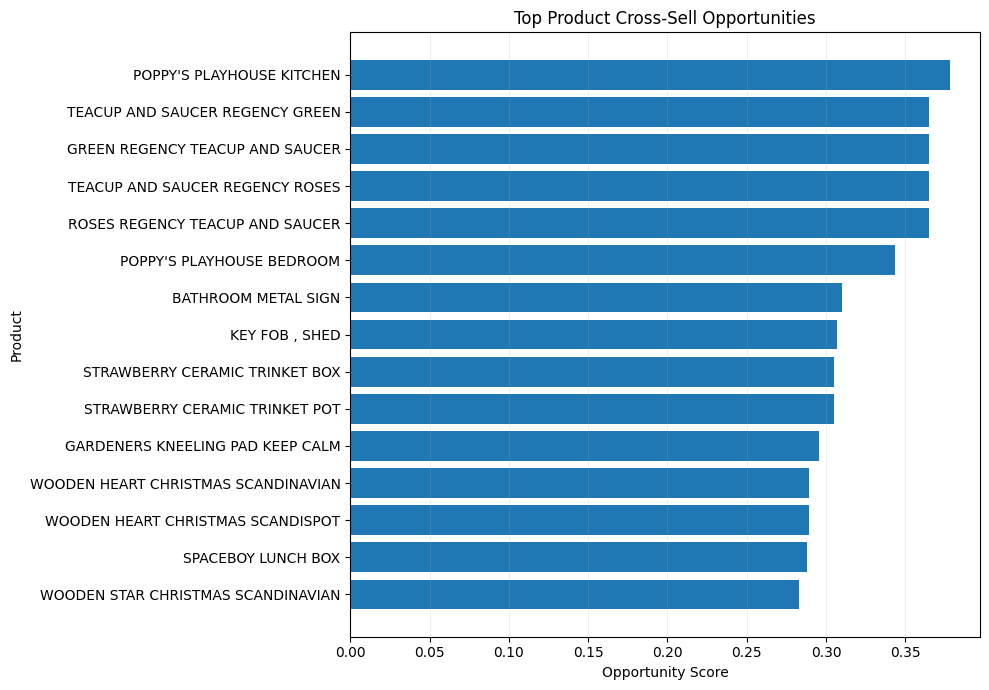

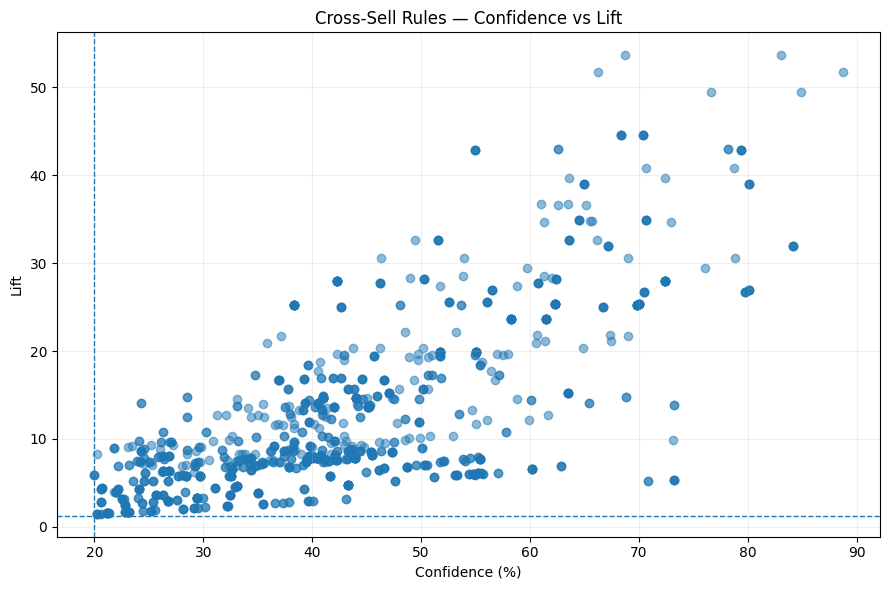


STEP 4 STATUS
One-to-one rules              : 1,191
Products with recommendations: 174
Products receiving rules     : 162
Opportunity products         : 236
PASS — Cross-sell recommendation engine completed.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [6]:
# ============================================================
# PROJECT 20 — MARKET BASKET ANALYSIS & CROSS-SELL INTELLIGENCE
# STEP 4 — CROSS-SELL RECOMMENDATION ENGINE
# ROBUST VERSION — NO DEPENDENCY ON product_frequency
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 90)
print("CROSS-SELL RECOMMENDATION ENGINE")
print("=" * 90)

# ------------------------------------------------------------
# 1. Validate required objects
# ------------------------------------------------------------

required_objects = [
    "basket_df",
    "simple_rules"
]

missing_objects = [
    obj
    for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise ValueError(
        "Missing objects: "
        + str(missing_objects)
        + ". Jalankan STEP 1 dan STEP 3 terlebih dahulu."
    )

# ------------------------------------------------------------
# 2. Rebuild product statistics directly from basket_df
# ------------------------------------------------------------

product_stats = (
    basket_df
    .groupby(
        [
            "StockCode",
            "Description"
        ],
        as_index=False
    )
    .agg(
        Transactions=(
            "InvoiceNo",
            "nunique"
        ),

        Units_Sold=(
            "Quantity",
            "sum"
        ),

        Revenue=(
            "Revenue",
            "sum"
        )
    )
)

# ------------------------------------------------------------
# 3. Clean product codes
# ------------------------------------------------------------

product_stats[
    "StockCode"
] = (
    product_stats[
        "StockCode"
    ]
    .astype(str)
    .str.strip()
)

# ------------------------------------------------------------
# 4. Create product description lookup
# ------------------------------------------------------------

description_lookup = (
    product_stats
    .drop_duplicates(
        subset=[
            "StockCode"
        ]
    )
    .set_index(
        "StockCode"
    )[
        "Description"
    ]
    .to_dict()
)

# ------------------------------------------------------------
# 5. Prepare recommendation rules
# ------------------------------------------------------------

recommendation_rules = (
    simple_rules
    .copy()
)

if recommendation_rules.empty:
    raise ValueError(
        "Tidak ada one-to-one association rules."
    )

# ------------------------------------------------------------
# 6. Standardize rule product codes
# ------------------------------------------------------------

recommendation_rules[
    "Antecedent_Product"
] = (
    recommendation_rules[
        "Antecedent_Product"
    ]
    .astype(str)
    .str.strip()
)

recommendation_rules[
    "Consequent_Product"
] = (
    recommendation_rules[
        "Consequent_Product"
    ]
    .astype(str)
    .str.strip()
)

# ------------------------------------------------------------
# 7. Create internal recommendation score
# ------------------------------------------------------------

recommendation_rules[
    "Recommendation_Score"
] = (
    recommendation_rules[
        "confidence"
    ]
    *
    np.log1p(
        recommendation_rules[
            "lift"
        ]
    )
    *
    np.sqrt(
        recommendation_rules[
            "support"
        ]
    )
)

# ------------------------------------------------------------
# 8. Build antecedent statistics
# ------------------------------------------------------------

antecedent_stats = (
    product_stats[
        [
            "StockCode",
            "Transactions",
            "Units_Sold",
            "Revenue"
        ]
    ]
    .copy()
    .rename(
        columns={
            "StockCode":
                "Antecedent_Product",

            "Transactions":
                "Antecedent_Transactions",

            "Units_Sold":
                "Antecedent_Units_Sold",

            "Revenue":
                "Antecedent_Revenue"
        }
    )
)

# ------------------------------------------------------------
# 9. Build consequent statistics
# ------------------------------------------------------------

consequent_stats = (
    product_stats[
        [
            "StockCode",
            "Transactions",
            "Units_Sold",
            "Revenue"
        ]
    ]
    .copy()
    .rename(
        columns={
            "StockCode":
                "Consequent_Product",

            "Transactions":
                "Consequent_Transactions",

            "Units_Sold":
                "Consequent_Units_Sold",

            "Revenue":
                "Consequent_Revenue"
        }
    )
)

# ------------------------------------------------------------
# 10. Merge antecedent statistics
# ------------------------------------------------------------

recommendation_rules = (
    recommendation_rules
    .merge(
        antecedent_stats,
        on="Antecedent_Product",
        how="left"
    )
)

# ------------------------------------------------------------
# 11. Merge consequent statistics
# ------------------------------------------------------------

recommendation_rules = (
    recommendation_rules
    .merge(
        consequent_stats,
        on="Consequent_Product",
        how="left"
    )
)

# ------------------------------------------------------------
# 12. Add descriptions
# ------------------------------------------------------------

recommendation_rules[
    "Antecedent_Description"
] = (
    recommendation_rules[
        "Antecedent_Product"
    ]
    .map(
        description_lookup
    )
)

recommendation_rules[
    "Consequent_Description"
] = (
    recommendation_rules[
        "Consequent_Product"
    ]
    .map(
        description_lookup
    )
)

# ------------------------------------------------------------
# 13. Rank recommendations per product
# ------------------------------------------------------------

recommendation_rules[
    "Product_Rank"
] = (
    recommendation_rules
    .groupby(
        "Antecedent_Product"
    )[
        "Recommendation_Score"
    ]
    .rank(
        method="first",
        ascending=False
    )
)

# ------------------------------------------------------------
# 14. Top 5 recommendation per product
# ------------------------------------------------------------

top_recommendations = (
    recommendation_rules[
        recommendation_rules[
            "Product_Rank"
        ] <= 5
    ]
    .sort_values(
        [
            "Antecedent_Product",
            "Product_Rank"
        ]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 15. Top rules overall
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "TOP CROSS-SELL RECOMMENDATIONS"
)

print(
    "=" * 90
)

display(
    top_recommendations[
        [
            "Antecedent_Product",
            "Antecedent_Description",
            "Consequent_Product",
            "Consequent_Description",
            "Antecedent_Transactions",
            "Consequent_Transactions",
            "support",
            "confidence",
            "lift",
            "Recommendation_Score",
            "Product_Rank"
        ]
    ]
    .sort_values(
        "Recommendation_Score",
        ascending=False
    )
    .head(30)
)

# ------------------------------------------------------------
# 16. Recommendation function
# ------------------------------------------------------------

def recommend_products(
    product_code,
    top_n=5
):

    product_code = str(
        product_code
    ).strip()

    result = (
        recommendation_rules[
            recommendation_rules[
                "Antecedent_Product"
            ]
            ==
            product_code
        ]
        .sort_values(
            [
                "Recommendation_Score",
                "lift",
                "confidence",
                "support"
            ],
            ascending=[
                False,
                False,
                False,
                False
            ]
        )
        .head(
            top_n
        )
        .copy()
    )

    if result.empty:

        return pd.DataFrame({
            "Product": [],
            "Recommended_Product": [],
            "Recommended_Description": [],
            "Confidence_%": [],
            "Lift": [],
            "Support_%": []
        })

    return pd.DataFrame({

        "Product":
            product_code,

        "Recommended_Product":
            result[
                "Consequent_Product"
            ].values,

        "Recommended_Description":
            result[
                "Consequent_Description"
            ].values,

        "Confidence_%":
            result[
                "confidence"
            ].values
            * 100,

        "Lift":
            result[
                "lift"
            ].values,

        "Support_%":
            result[
                "support"
            ].values
            * 100
    })

# ------------------------------------------------------------
# 17. Demonstration
# ------------------------------------------------------------

demo_product = (
    recommendation_rules
    .sort_values(
        "Recommendation_Score",
        ascending=False
    )
    .iloc[0][
        "Antecedent_Product"
    ]
)

print(
    "\n" + "=" * 90
)

print(
    "RECOMMENDATION ENGINE DEMO"
)

print(
    "=" * 90
)

print(
    f"\nInput product: "
    f"{demo_product}"
)

print(
    f"Description: "
    f"{description_lookup.get(demo_product, 'Unknown')}"
)

display(
    recommend_products(
        demo_product,
        top_n=5
    )
)

# ------------------------------------------------------------
# 18. Product cross-sell opportunity
# ------------------------------------------------------------

product_opportunity = (
    recommendation_rules
    .groupby(
        "Consequent_Product"
    )
    .agg(

        Incoming_Rules=(
            "Antecedent_Product",
            "nunique"
        ),

        Average_Confidence=(
            "confidence",
            "mean"
        ),

        Maximum_Confidence=(
            "confidence",
            "max"
        ),

        Average_Lift=(
            "lift",
            "mean"
        ),

        Maximum_Lift=(
            "lift",
            "max"
        ),

        Average_Support=(
            "support",
            "mean"
        ),

        Opportunity_Score=(
            "Recommendation_Score",
            "mean"
        )
    )
    .reset_index()
)

# ------------------------------------------------------------
# 19. Merge product popularity
# ------------------------------------------------------------

product_opportunity = (
    product_opportunity
    .merge(
        product_stats[
            [
                "StockCode",
                "Description",
                "Transactions",
                "Units_Sold",
                "Revenue"
            ]
        ],
        left_on="Consequent_Product",
        right_on="StockCode",
        how="left"
    )
)

# Remove duplicate StockCode helper
product_opportunity = (
    product_opportunity
    .drop(
        columns=[
            "StockCode"
        ]
    )
)

# ------------------------------------------------------------
# 20. Sort opportunity products
# ------------------------------------------------------------

product_opportunity = (
    product_opportunity
    .sort_values(
        [
            "Opportunity_Score",
            "Incoming_Rules"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 21. Display product opportunities
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "PRODUCT CROSS-SELL OPPORTUNITIES"
)

print(
    "=" * 90
)

display(
    product_opportunity[
        [
            "Consequent_Product",
            "Description",
            "Transactions",
            "Units_Sold",
            "Revenue",
            "Incoming_Rules",
            "Average_Confidence",
            "Maximum_Confidence",
            "Average_Lift",
            "Maximum_Lift",
            "Opportunity_Score"
        ]
    ]
    .head(30)
)

# ------------------------------------------------------------
# 22. Identify high-frequency opportunity products
# ------------------------------------------------------------

frequency_threshold = (
    product_stats[
        "Transactions"
    ]
    .quantile(
        0.75
    )
)

high_frequency_products = (
    product_opportunity[
        product_opportunity[
            "Transactions"
        ]
        >=
        frequency_threshold
    ]
    .copy()
)

high_frequency_products = (
    high_frequency_products
    .sort_values(
        [
            "Opportunity_Score",
            "Transactions"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

print(
    "\n" + "=" * 90
)

print(
    "HIGH-FREQUENCY CROSS-SELL OPPORTUNITIES"
)

print(
    "=" * 90
)

print(
    f"\n75th percentile transaction frequency: "
    f"{frequency_threshold:.0f}"
)

display(
    high_frequency_products[
        [
            "Consequent_Product",
            "Description",
            "Transactions",
            "Revenue",
            "Incoming_Rules",
            "Average_Confidence",
            "Average_Lift",
            "Maximum_Lift",
            "Opportunity_Score"
        ]
    ]
    .head(25)
)

# ------------------------------------------------------------
# 23. Recommendation network summary
# ------------------------------------------------------------

network_summary = (
    recommendation_rules
    .groupby(
        "Antecedent_Product"
    )
    .agg(

        Recommendation_Count=(
            "Consequent_Product",
            "nunique"
        ),

        Average_Confidence=(
            "confidence",
            "mean"
        ),

        Average_Lift=(
            "lift",
            "mean"
        ),

        Maximum_Lift=(
            "lift",
            "max"
        )
    )
    .reset_index()
)

network_summary[
    "Description"
] = (
    network_summary[
        "Antecedent_Product"
    ]
    .map(
        description_lookup
    )
)

network_summary = (
    network_summary
    .sort_values(
        [
            "Recommendation_Count",
            "Average_Lift"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

print(
    "\n" + "=" * 90
)

print(
    "PRODUCT RECOMMENDATION NETWORK"
)

print(
    "=" * 90
)

display(
    network_summary.head(20)
)

# ------------------------------------------------------------
# 24. Opportunity visualization
# ------------------------------------------------------------

plot_opportunities = (
    product_opportunity
    .head(15)
    .sort_values(
        "Opportunity_Score"
    )
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    plot_opportunities[
        "Description"
    ]
    .astype(str)
    .str[:40],

    plot_opportunities[
        "Opportunity_Score"
    ]
)

plt.title(
    "Top Product Cross-Sell Opportunities"
)

plt.xlabel(
    "Opportunity Score"
)

plt.ylabel(
    "Product"
)

plt.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 25. Confidence vs Lift
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 6)
)

plt.scatter(
    recommendation_rules[
        "confidence"
    ] * 100,

    recommendation_rules[
        "lift"
    ],

    alpha=0.5
)

plt.axvline(
    20,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    1.2,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Confidence (%)"
)

plt.ylabel(
    "Lift"
)

plt.title(
    "Cross-Sell Rules — Confidence vs Lift"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 26. Store outputs
# ------------------------------------------------------------

cross_sell_results = {

    "recommendation_rules":
        recommendation_rules,

    "top_recommendations":
        top_recommendations,

    "product_opportunity":
        product_opportunity,

    "high_frequency_products":
        high_frequency_products,

    "network_summary":
        network_summary
}

# ------------------------------------------------------------
# 27. Final status
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "STEP 4 STATUS"
)

print(
    "=" * 90
)

print(
    f"One-to-one rules              : "
    f"{len(recommendation_rules):,}"
)

print(
    f"Products with recommendations: "
    f"{recommendation_rules['Antecedent_Product'].nunique():,}"
)

print(
    f"Products receiving rules     : "
    f"{recommendation_rules['Consequent_Product'].nunique():,}"
)

print(
    f"Opportunity products         : "
    f"{len(product_opportunity):,}"
)

print(
    "PASS — Cross-sell recommendation engine completed."
)

CROSS-SELL IMPACT SIMULATION

Rules before validation : 457
Rules after validation  : 457

CROSS-SELL SCENARIO ANALYSIS


,Scenario,Assumed_Response_Rate_%,Estimated_Conversions,Estimated_Incremental_Revenue
0,Conservative,5.0,10502.0,290052.18
1,Base,10.0,21003.0,580104.35
2,Optimistic,20.0,42007.0,1160208.70



TOP CROSS-SELL REVENUE OPPORTUNITIES


,Antecedent_Product,Antecedent_Description,Consequent_Product,Consequent_Description,Antecedent_Transactions,Consequent_Transactions,support,confidence,lift,Expected_Conversions,Consequent_Avg_Transaction_Revenue,Expected_Incremental_Revenue
0,21733,RED HANGING HEART T-LIGHT HOLDER,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1631,4888,0.032158,0.708155,5.195930,115.500000,51.499849,5948.232514
1,22699,ROSES REGENCY TEACUP AND SAUCER,22423,REGENCY CAKESTAND 3 TIER,1056,3317,0.016372,0.549533,5.950261,58.030654,86.220184,5003.413678
2,85099F,JUMBO BAG STRAWBERRY,85099B,JUMBO BAG RED RETROSPOT,1514,2612,0.026506,0.628798,6.927578,95.200000,52.329552,4981.773357
3,21931,JUMBO STORAGE BAG SUKI,85099B,JUMBO BAG RED RETROSPOT,1714,2612,0.025420,0.532672,5.868543,91.300000,52.329552,4777.688104
4,22697,GREEN REGENCY TEACUP AND SAUCER,22423,REGENCY CAKESTAND 3 TIER,933,3317,0.014673,0.557082,6.032009,51.975793,86.220184,4481.362415
5,85099C,JUMBO BAG BAROQUE BLACK WHITE,85099B,JUMBO BAG RED RETROSPOT,1449,2612,0.022386,0.554865,6.113051,80.400000,52.329552,4207.295986
6,22411,JUMBO SHOPPER VINTAGE RED PAISLEY,85099B,JUMBO BAG RED RETROSPOT,1680,2612,0.022274,0.476190,5.246275,80.000000,52.329552,4186.364165
7,22698,PINK REGENCY TEACUP AND SAUCER,22423,REGENCY CAKESTAND 3 TIER,746,3317,0.012000,0.570861,6.181200,42.586225,86.220184,3671.792165
8,85099B,JUMBO BAG RED RETROSPOT,22386,JUMBO BAG PINK POLKADOT,2612,1055,0.029625,0.326380,6.634000,85.250552,41.636076,3549.498454
9,85123A,WHITE HANGING HEART T-LIGHT HOLDER,21733,RED HANGING HEART T-LIGHT HOLDER,4888,1631,0.032158,0.235955,5.195930,115.334831,30.592152,3528.340701



PRODUCT-LEVEL CROSS-SELL IMPACT


,Consequent_Product,Description,Transactions,Units_Sold,Revenue,Cross_Sell_Rules,Total_Expected_Conversions,Total_Expected_Revenue,Average_Confidence,Average_Lift,Maximum_Lift
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,4888,93520,251731.26,29,1359.069883,69991.893227,0.323964,2.377013,5.374841
1,85099B,JUMBO BAG RED RETROSPOT,2612,75597,136684.79,21,1110.612209,58117.839395,0.433103,4.771578,6.927578
2,22386,JUMBO BAG PINK POLKADOT,1055,23914,43926.06,10,514.086049,21404.525724,0.376676,7.656299,9.650129
3,20725,LUNCH BAG RED RETROSPOT,1520,20668,32742.60,17,870.053392,18741.980381,0.385669,5.370952,7.714204
4,22423,REGENCY CAKESTAND 3 TIER,3317,24858,285992.35,4,182.135753,15703.778094,0.494428,5.353592,6.181200
5,21931,JUMBO STORAGE BAG SUKI,1714,26225,48228.24,12,521.656719,14678.287878,0.350119,7.336557,9.668071
6,85099F,JUMBO BAG STRAWBERRY,1514,36046,64495.57,7,336.048878,14315.497956,0.332833,7.895666,9.068020
7,22383,LUNCH BAG SUKI DESIGN,1073,14229,22555.85,13,677.595279,14243.930546,0.372883,6.682865,8.981631
8,85099C,JUMBO BAG BAROQUE BLACK WHITE,1449,29351,52979.58,7,304.734820,11141.975697,0.296365,7.345918,8.251335
9,21929,JUMBO BAG PINK VINTAGE PAISLEY,1228,24414,43850.60,7,286.949532,10246.668680,0.291212,8.517253,14.573868



CROSS-SELL OPPORTUNITY RATIO


,Consequent_Product,Description,Revenue,Total_Expected_Revenue,Opportunity_to_Revenue_Ratio,Average_Confidence,Average_Lift
7,22383,LUNCH BAG SUKI DESIGN,22555.85,14243.930546,0.631496,0.372883,6.682865
3,20725,LUNCH BAG RED RETROSPOT,32742.60,18741.980381,0.572404,0.385669,5.370952
2,22386,JUMBO BAG PINK POLKADOT,43926.06,21404.525724,0.487285,0.376676,7.656299
15,22384,LUNCH BAG PINK POLKADOT,18513.90,7976.035565,0.430813,0.372515,7.251621
1,85099B,JUMBO BAG RED RETROSPOT,136684.79,58117.839395,0.425196,0.433103,4.771578
13,21212,PACK OF 72 RETROSPOT CAKE CASES,22180.71,8489.661351,0.382750,0.469180,6.718925
10,21928,JUMBO BAG SCANDINAVIAN PAISLEY,27641.65,9882.106787,0.357508,0.303331,9.295587
5,21931,JUMBO STORAGE BAG SUKI,48228.24,14678.287878,0.304350,0.350119,7.336557
70,22356,CHARLOTTE BAG PINK POLKADOT,6877.54,1967.819855,0.286123,0.439557,14.248299
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,251731.26,69991.893227,0.278042,0.323964,2.377013


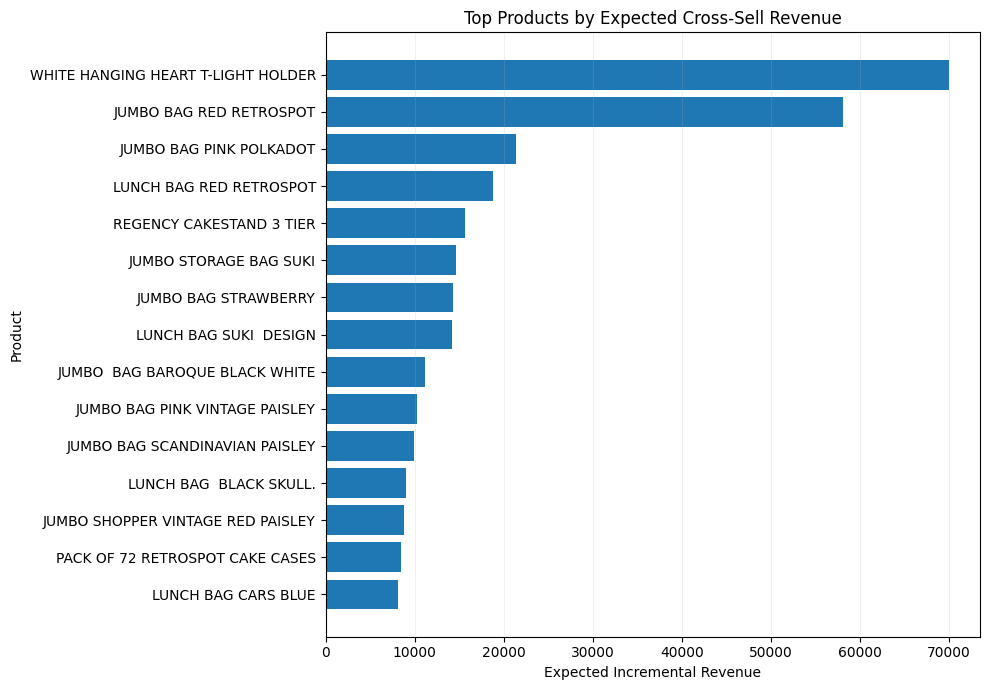

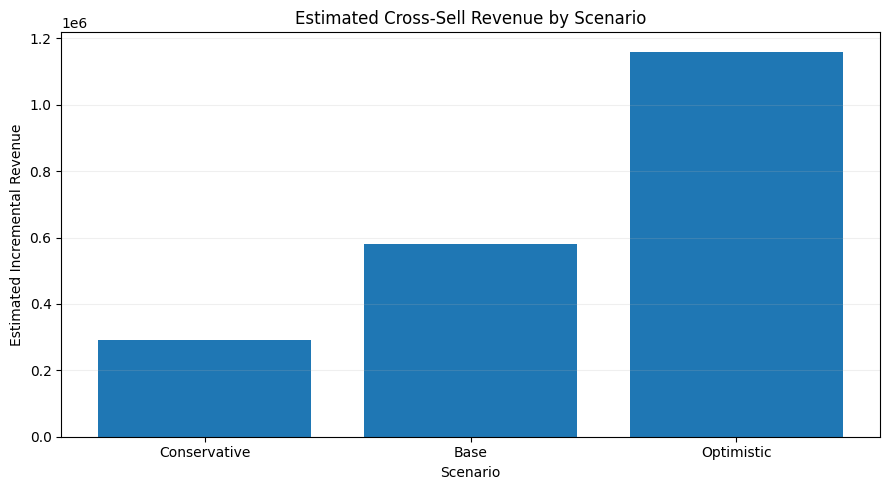

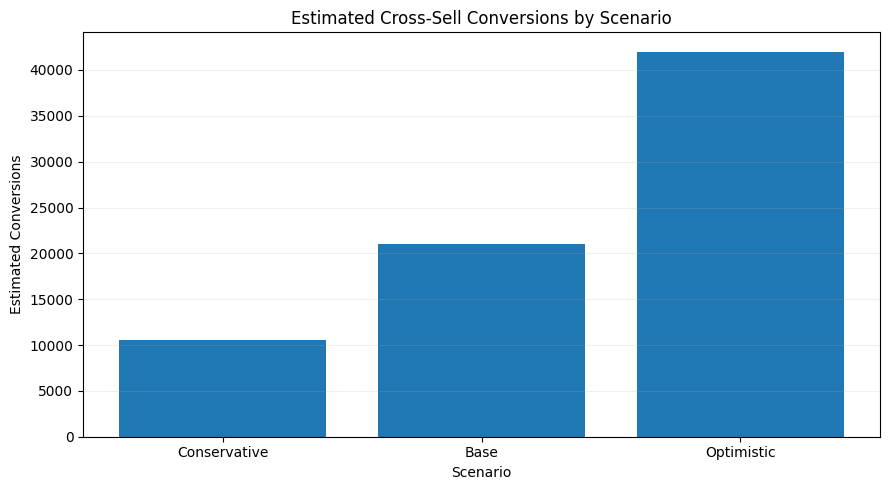


CROSS-SELL EXECUTIVE SUMMARY

Base response assumption : 10%
Estimated conversions    : 21,003
Estimated revenue        : 580,104.35

Top opportunity product:
WHITE HANGING HEART T-LIGHT HOLDER
Expected revenue opportunity: 69,991.89

IMPORTANT:
Simulation results are scenario-based estimates.
They are not causal estimates, observed conversion rates, or guaranteed incremental revenue.

STEP 5 STATUS
Rules evaluated          : 457
Scenarios evaluated      : 3
Rule opportunities       : 457
Product opportunities    : 162
PASS — Cross-sell impact simulation completed.


In [9]:
# ============================================================
# PROJECT 20 — MARKET BASKET ANALYSIS & CROSS-SELL INTELLIGENCE
# STEP 5 — CROSS-SELL IMPACT SIMULATION
# CLEAN VERSION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 90)
print("CROSS-SELL IMPACT SIMULATION")
print("=" * 90)

# ------------------------------------------------------------
# 1. Validate required objects
# ------------------------------------------------------------

required_objects = [
    "basket_df",
    "simple_rules"
]

missing_objects = [
    obj
    for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise ValueError(
        "Missing objects: "
        + str(missing_objects)
        + ". Jalankan STEP 1 dan STEP 3 terlebih dahulu."
    )

# ------------------------------------------------------------
# 2. Rebuild product statistics from basket_df
# ------------------------------------------------------------

product_stats = (
    basket_df
    .groupby(
        [
            "StockCode",
            "Description"
        ],
        as_index=False
    )
    .agg(
        Transactions=(
            "InvoiceNo",
            "nunique"
        ),

        Units_Sold=(
            "Quantity",
            "sum"
        ),

        Revenue=(
            "Revenue",
            "sum"
        )
    )
)

# ------------------------------------------------------------
# 3. Standardize product codes
# ------------------------------------------------------------

product_stats[
    "StockCode"
] = (
    product_stats[
        "StockCode"
    ]
    .astype(str)
    .str.strip()
)

# ------------------------------------------------------------
# 4. Keep one descriptive record per product
# ------------------------------------------------------------

product_stats = (
    product_stats
    .sort_values(
        "Transactions",
        ascending=False
    )
    .drop_duplicates(
        subset=[
            "StockCode"
        ]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 5. Product lookup dictionaries
# ------------------------------------------------------------

description_lookup = dict(
    zip(
        product_stats[
            "StockCode"
        ],
        product_stats[
            "Description"
        ]
    )
)

transaction_lookup = dict(
    zip(
        product_stats[
            "StockCode"
        ],
        product_stats[
            "Transactions"
        ]
    )
)

units_lookup = dict(
    zip(
        product_stats[
            "StockCode"
        ],
        product_stats[
            "Units_Sold"
        ]
    )
)

revenue_lookup = dict(
    zip(
        product_stats[
            "StockCode"
        ],
        product_stats[
            "Revenue"
        ]
    )
)

# ------------------------------------------------------------
# 6. Average revenue per transaction
# ------------------------------------------------------------

avg_revenue_lookup = (
    product_stats
    .assign(
        Revenue_Per_Transaction=(
            product_stats[
                "Revenue"
            ]
            /
            product_stats[
                "Transactions"
            ]
        )
    )
    .set_index(
        "StockCode"
    )[
        "Revenue_Per_Transaction"
    ]
    .to_dict()
)

# ------------------------------------------------------------
# 7. Rebuild rules ONLY from simple_rules
# ------------------------------------------------------------

rules = (
    simple_rules[
        [
            "Antecedent_Product",
            "Consequent_Product",
            "support",
            "confidence",
            "lift"
        ]
    ]
    .copy()
)

# ------------------------------------------------------------
# 8. Standardize product code types
# ------------------------------------------------------------

rules[
    "Antecedent_Product"
] = (
    rules[
        "Antecedent_Product"
    ]
    .astype(str)
    .str.strip()
)

rules[
    "Consequent_Product"
] = (
    rules[
        "Consequent_Product"
    ]
    .astype(str)
    .str.strip()
)

# ------------------------------------------------------------
# 9. Add product descriptions
# ------------------------------------------------------------

rules[
    "Antecedent_Description"
] = (
    rules[
        "Antecedent_Product"
    ]
    .map(
        description_lookup
    )
)

rules[
    "Consequent_Description"
] = (
    rules[
        "Consequent_Product"
    ]
    .map(
        description_lookup
    )
)

# ------------------------------------------------------------
# 10. Add product transaction frequency
# ------------------------------------------------------------

rules[
    "Antecedent_Transactions"
] = (
    rules[
        "Antecedent_Product"
    ]
    .map(
        transaction_lookup
    )
)

rules[
    "Consequent_Transactions"
] = (
    rules[
        "Consequent_Product"
    ]
    .map(
        transaction_lookup
    )
)

# ------------------------------------------------------------
# 11. Add product revenue
# ------------------------------------------------------------

rules[
    "Consequent_Revenue"
] = (
    rules[
        "Consequent_Product"
    ]
    .map(
        revenue_lookup
    )
)

rules[
    "Consequent_Avg_Transaction_Revenue"
] = (
    rules[
        "Consequent_Product"
    ]
    .map(
        avg_revenue_lookup
    )
)

# ------------------------------------------------------------
# 12. Remove rules with missing product statistics
# ------------------------------------------------------------

before_filter = len(
    rules
)

rules = (
    rules[
        rules[
            "Antecedent_Transactions"
        ].notna()
        &
        rules[
            "Consequent_Transactions"
        ].notna()
        &
        rules[
            "Consequent_Avg_Transaction_Revenue"
        ].notna()
    ]
    .copy()
    .reset_index(drop=True)
)

after_filter = len(
    rules
)

print(
    f"\nRules before validation : "
    f"{before_filter:,}"
)

print(
    f"Rules after validation  : "
    f"{after_filter:,}"
)

# ------------------------------------------------------------
# 13. Simulation assumptions
# ------------------------------------------------------------

scenarios = {
    "Conservative": 0.05,
    "Base": 0.10,
    "Optimistic": 0.20
}

# Important:
# These are hypothetical response assumptions.
# They are NOT observed conversion rates.

# ------------------------------------------------------------
# 14. Run simulation
# ------------------------------------------------------------

simulation_results = []

for scenario_name, response_rate in (
    scenarios.items()
):

    total_conversions = 0.0
    total_revenue = 0.0

    for _, row in rules.iterrows():

        antecedent_transactions = (
            float(
                row[
                    "Antecedent_Transactions"
                ]
            )
        )

        confidence = (
            float(
                row[
                    "confidence"
                ]
            )
        )

        average_consequent_revenue = (
            float(
                row[
                    "Consequent_Avg_Transaction_Revenue"
                ]
            )
        )

        # Estimated customer exposures
        estimated_exposure = (
            antecedent_transactions
            *
            response_rate
        )

        # Expected cross-sell conversions
        expected_conversions = (
            estimated_exposure
            *
            confidence
        )

        # Estimated additional revenue
        expected_revenue = (
            expected_conversions
            *
            average_consequent_revenue
        )

        total_conversions += (
            expected_conversions
        )

        total_revenue += (
            expected_revenue
        )

    simulation_results.append({
        "Scenario":
            scenario_name,

        "Assumed_Response_Rate_%":
            response_rate * 100,

        "Estimated_Conversions":
            total_conversions,

        "Estimated_Incremental_Revenue":
            total_revenue
    })

simulation_summary = pd.DataFrame(
    simulation_results
)

simulation_summary[
    "Estimated_Conversions"
] = (
    simulation_summary[
        "Estimated_Conversions"
    ]
    .round(0)
)

simulation_summary[
    "Estimated_Incremental_Revenue"
] = (
    simulation_summary[
        "Estimated_Incremental_Revenue"
    ]
    .round(2)
)

# ------------------------------------------------------------
# 15. Display scenario analysis
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "CROSS-SELL SCENARIO ANALYSIS"
)

print(
    "=" * 90
)

display(
    simulation_summary
)

# ------------------------------------------------------------
# 16. Base-case simulation
# ------------------------------------------------------------

base_response_rate = (
    scenarios[
        "Base"
    ]
)

base_rules = (
    rules
    .copy()
)

base_rules[
    "Expected_Exposure"
] = (
    base_rules[
        "Antecedent_Transactions"
    ]
    *
    base_response_rate
)

base_rules[
    "Expected_Conversions"
] = (
    base_rules[
        "Expected_Exposure"
    ]
    *
    base_rules[
        "confidence"
    ]
)

base_rules[
    "Expected_Incremental_Revenue"
] = (
    base_rules[
        "Expected_Conversions"
    ]
    *
    base_rules[
        "Consequent_Avg_Transaction_Revenue"
    ]
)

# ------------------------------------------------------------
# 17. Rank individual rule opportunities
# ------------------------------------------------------------

top_opportunities = (
    base_rules
    .sort_values(
        [
            "Expected_Incremental_Revenue",
            "lift",
            "confidence"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 18. Display top rule opportunities
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "TOP CROSS-SELL REVENUE OPPORTUNITIES"
)

print(
    "=" * 90
)

display(
    top_opportunities[
        [
            "Antecedent_Product",
            "Antecedent_Description",
            "Consequent_Product",
            "Consequent_Description",
            "Antecedent_Transactions",
            "Consequent_Transactions",
            "support",
            "confidence",
            "lift",
            "Expected_Conversions",
            "Consequent_Avg_Transaction_Revenue",
            "Expected_Incremental_Revenue"
        ]
    ]
    .head(30)
)

# ------------------------------------------------------------
# 19. Product-level impact aggregation
# ------------------------------------------------------------

product_impact = (
    base_rules
    .groupby(
        "Consequent_Product",
        as_index=False
    )
    .agg(
        Cross_Sell_Rules=(
            "Antecedent_Product",
            "nunique"
        ),

        Total_Expected_Conversions=(
            "Expected_Conversions",
            "sum"
        ),

        Total_Expected_Revenue=(
            "Expected_Incremental_Revenue",
            "sum"
        ),

        Average_Confidence=(
            "confidence",
            "mean"
        ),

        Average_Lift=(
            "lift",
            "mean"
        ),

        Maximum_Lift=(
            "lift",
            "max"
        )
    )
)

# ------------------------------------------------------------
# 20. Add product information using map
# ------------------------------------------------------------

product_impact[
    "Description"
] = (
    product_impact[
        "Consequent_Product"
    ]
    .map(
        description_lookup
    )
)

product_impact[
    "Transactions"
] = (
    product_impact[
        "Consequent_Product"
    ]
    .map(
        transaction_lookup
    )
)

product_impact[
    "Units_Sold"
] = (
    product_impact[
        "Consequent_Product"
    ]
    .map(
        units_lookup
    )
)

product_impact[
    "Revenue"
] = (
    product_impact[
        "Consequent_Product"
    ]
    .map(
        revenue_lookup
    )
)

# ------------------------------------------------------------
# 21. Sort product opportunities
# ------------------------------------------------------------

product_impact = (
    product_impact
    .sort_values(
        [
            "Total_Expected_Revenue",
            "Cross_Sell_Rules"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 22. Display product-level impact
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "PRODUCT-LEVEL CROSS-SELL IMPACT"
)

print(
    "=" * 90
)

display(
    product_impact[
        [
            "Consequent_Product",
            "Description",
            "Transactions",
            "Units_Sold",
            "Revenue",
            "Cross_Sell_Rules",
            "Total_Expected_Conversions",
            "Total_Expected_Revenue",
            "Average_Confidence",
            "Average_Lift",
            "Maximum_Lift"
        ]
    ]
    .head(30)
)

# ------------------------------------------------------------
# 23. Opportunity-to-current-revenue ratio
# ------------------------------------------------------------

product_impact[
    "Opportunity_to_Revenue_Ratio"
] = np.where(
    product_impact[
        "Revenue"
    ] > 0,

    product_impact[
        "Total_Expected_Revenue"
    ]
    /
    product_impact[
        "Revenue"
    ],

    0
)

# ------------------------------------------------------------
# 24. Display ratio analysis
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "CROSS-SELL OPPORTUNITY RATIO"
)

print(
    "=" * 90
)

display(
    product_impact[
        [
            "Consequent_Product",
            "Description",
            "Revenue",
            "Total_Expected_Revenue",
            "Opportunity_to_Revenue_Ratio",
            "Average_Confidence",
            "Average_Lift"
        ]
    ]
    .sort_values(
        "Opportunity_to_Revenue_Ratio",
        ascending=False
    )
    .head(25)
)

# ------------------------------------------------------------
# 25. Top product visualization
# ------------------------------------------------------------

plot_data = (
    product_impact
    .head(15)
    .sort_values(
        "Total_Expected_Revenue"
    )
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    plot_data[
        "Description"
    ]
    .astype(str)
    .str[:40],

    plot_data[
        "Total_Expected_Revenue"
    ]
)

plt.title(
    "Top Products by Expected Cross-Sell Revenue"
)

plt.xlabel(
    "Expected Incremental Revenue"
)

plt.ylabel(
    "Product"
)

plt.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 26. Scenario revenue visualization
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    simulation_summary[
        "Scenario"
    ],

    simulation_summary[
        "Estimated_Incremental_Revenue"
    ]
)

plt.title(
    "Estimated Cross-Sell Revenue by Scenario"
)

plt.xlabel(
    "Scenario"
)

plt.ylabel(
    "Estimated Incremental Revenue"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 27. Scenario conversion visualization
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    simulation_summary[
        "Scenario"
    ],

    simulation_summary[
        "Estimated_Conversions"
    ]
)

plt.title(
    "Estimated Cross-Sell Conversions by Scenario"
)

plt.xlabel(
    "Scenario"
)

plt.ylabel(
    "Estimated Conversions"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 28. Executive summary
# ------------------------------------------------------------

base_case = (
    simulation_summary[
        simulation_summary[
            "Scenario"
        ]
        ==
        "Base"
    ]
    .iloc[0]
)

best_product = (
    product_impact
    .iloc[0]
)

print(
    "\n" + "=" * 90
)

print(
    "CROSS-SELL EXECUTIVE SUMMARY"
)

print(
    "=" * 90
)

print(
    f"\nBase response assumption : "
    f"{base_case['Assumed_Response_Rate_%']:.0f}%"
)

print(
    f"Estimated conversions    : "
    f"{base_case['Estimated_Conversions']:,.0f}"
)

print(
    f"Estimated revenue        : "
    f"{base_case['Estimated_Incremental_Revenue']:,.2f}"
)

print(
    f"\nTop opportunity product:"
)

print(
    f"{best_product['Description']}"
)

print(
    f"Expected revenue opportunity: "
    f"{best_product['Total_Expected_Revenue']:,.2f}"
)

print(
    "\nIMPORTANT:"
)

print(
    "Simulation results are scenario-based estimates."
)

print(
    "They are not causal estimates, observed conversion rates, "
    "or guaranteed incremental revenue."
)

# ------------------------------------------------------------
# 29. Store final results
# ------------------------------------------------------------

cross_sell_simulation = {
    "simulation_summary":
        simulation_summary,

    "top_opportunities":
        top_opportunities,

    "product_impact":
        product_impact
}

# ------------------------------------------------------------
# 30. Final status
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "STEP 5 STATUS"
)

print(
    "=" * 90
)

print(
    f"Rules evaluated          : "
    f"{len(rules):,}"
)

print(
    f"Scenarios evaluated      : "
    f"{len(simulation_summary)}"
)

print(
    f"Rule opportunities       : "
    f"{len(top_opportunities):,}"
)

print(
    f"Product opportunities    : "
    f"{len(product_impact):,}"
)

print(
    "PASS — Cross-sell impact simulation completed."
)

## Key Findings

### 1. Strong product associations exist within customer baskets

The market basket analysis generated 844 association rules, with 741 rules passing the defined business thresholds in the initial analysis.

The results demonstrate that several products have strong co-purchasing relationships.

### 2. Some associations demonstrate very high lift

The strongest observed rules achieved lift values above 50, indicating strong association relative to the baseline frequency of the consequent products.

However, high lift must be interpreted together with support and confidence because highly specific or relatively uncommon product combinations can produce extreme lift values.

### 3. Product associations can be transformed into cross-sell recommendations

The association rules were converted into one-to-one recommendation rules and used to build a cross-sell recommendation engine.

The final recommendation layer evaluated 457 valid product-to-product rules.

### 4. Cross-sell opportunities are concentrated among specific product groups

Products such as:

- WHITE HANGING HEART T-LIGHT HOLDER
- JUMBO BAG RED RETROSPOT
- JUMBO BAG PINK POLKADOT
- LUNCH BAG RED RETROSPOT
- REGENCY CAKESTAND 3 TIER

appeared among the strongest product-level cross-sell opportunities.

### 5. Product popularity and association strength should be evaluated together

A product with high lift is not necessarily the strongest business opportunity.

The project therefore combines:

- Transaction frequency
- Support
- Confidence
- Lift
- Expected cross-sell revenue

to prioritize opportunities.

### 6. Cross-sell impact depends heavily on response assumptions

Under the simulation framework:

- Conservative scenario: approximately 10,502 estimated conversions
- Base scenario: approximately 21,003 estimated conversions
- Optimistic scenario: approximately 42,007 estimated conversions

The corresponding estimated incremental revenue was approximately 290,052, 580,104, and 1,160,209 respectively.

These figures are scenario-based estimates rather than observed business impact.

### 7. Association analysis can support product recommendation systems

The final recommendation engine can answer:

> "A customer has purchased product A. Which products have the strongest historical association with A?"

This makes the analysis applicable to product bundling, recommendation systems, cross-selling, and merchandising strategies.

## Business Recommendations

### Use Association Rules for Cross-Selling

Products with strong confidence and lift can be recommended together during checkout, email campaigns, or product browsing.

### Prioritize High-Frequency Opportunities

Cross-sell strategies should prioritize products that have both strong association metrics and sufficient transaction volume.

This reduces the risk of focusing on extremely rare combinations with limited commercial relevance.

### Create Product Bundles

Frequently associated product combinations can be used to design product bundles or promotional packages.

### Personalize Recommendations

The recommendation engine can be integrated into customer-facing systems so that recommended products depend on the products currently present in the customer's basket.

### Use Different Campaign Strategies

High-confidence relationships can support direct recommendations, while high-lift but lower-support relationships may be better suited for niche or personalized campaigns.

### Validate Recommendations Experimentally

The current impact simulation is not a causal analysis.

Before deployment, recommended product combinations should be tested through A/B experiments or controlled campaigns to measure actual incremental conversions and revenue.

### Continuously Update Association Rules

Product relationships can change over time.

A production system should periodically recompute frequent itemsets and association rules using recent transaction data.

## Conclusion

This project developed a Market Basket Analysis and Cross-Sell Intelligence framework using transaction-level retail data.

The project transformed cleaned transaction records into customer baskets, identified frequent product combinations using FP-Growth, generated association rules, and evaluated product relationships using support, confidence, lift, leverage, and conviction.

The analysis demonstrated that several product combinations have strong historical associations.

These relationships were subsequently transformed into a cross-sell recommendation engine capable of identifying recommended products for a given product.

The final system evaluated 457 valid one-to-one recommendation rules and identified 162 products that could act as recommendation targets.

A scenario-based impact simulation was then performed using conservative, base, and optimistic response assumptions.

Under the 10% base-response scenario, the model estimated approximately 21,003 cross-sell conversions and 580,104.35 in potential incremental revenue.

These values are simulation outputs and should not be interpreted as observed or guaranteed business impact.

Overall, the project demonstrates how transactional data can be transformed from simple purchase records into product association intelligence and actionable cross-selling strategies.

The project provides a foundation for integrating market basket analysis with recommendation systems, customer segmentation, CLV, and real-time personalization.